# 🔍 EDA Détaillée — Hate Speech Detection

**Dataset** : `HateSpeechData.csv` · 24 783 tweets · 3 classes  
**Objectif** : Comprendre profondément la structure des données avant toute modélisation

---
| # | Section |
|---|---|
| 1 | Imports & Configuration |
| 2 | Chargement & Aperçu général |
| 3 | Distribution des classes & Déséquilibre |
| 4 | Accord inter-annotateurs |
| 5 | Analyse textuelle (longueur, mots, tokens) |
| 6 | Features stylistiques (majuscules, ponctuation, mentions) |
| 7 | Vocabulaire & Overlap entre classes |
| 8 | WordClouds par classe |
| 9 | N-grammes discriminants |
| 10 | Analyse des doublons & qualité des données |
| 11 | Corrélations entre features |
| 12 | Synthèse & Recommandations |


## 1 · Imports & Configuration

In [10]:
# ── Installations ─────────────────────────────────────────────────────
!pip install wordcloud nltk matplotlib seaborn pandas numpy scipy -q
import nltk
for r in ['stopwords','punkt','wordnet','omw-1.4']:
    nltk.download(r, quiet=True)


In [11]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import chi2_contingency, pointbiserialr

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# ── Palette & style ───────────────────────────────────────────────────
COLORS      = ['#E63946', '#F4A261', '#2A9D8F']    # rouge · orange · vert
CLASS_NAMES = ['hate_speech', 'offensive', 'neither']
LABEL_MAP   = {0: 'hate_speech', 1: 'offensive', 2: 'neither'}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

STOP = set(stopwords.words('english')) | {'rt', 'http', 'https', 'co', 'amp', 'u', 'im'}

def sep(title):
    print(f"\n{'═'*65}")
    print(f"  {title}")
    print(f"{'═'*65}")

print('✓ Configuration prête')


✓ Configuration prête


## 2 · Chargement & Aperçu général

In [12]:
sep('2. CHARGEMENT DES DONNÉES')

df = pd.read_csv('HateSpeechData.csv').drop(columns=['Unnamed: 0'], errors='ignore')
df['label'] = df['class'].map(LABEL_MAP)
df['confidence'] = df.apply(
    lambda r: max(r.hate_speech, r.offensive_language, r.neither) / r['count'], axis=1)

print(f'Shape          : {df.shape}')
print(f'Colonnes       : {list(df.columns)}')
print(f'Types          :\n{df.dtypes}')
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')
display(df.head(5))



═════════════════════════════════════════════════════════════════
  2. CHARGEMENT DES DONNÉES
═════════════════════════════════════════════════════════════════
Shape          : (24783, 8)
Colonnes       : ['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'label', 'confidence']
Types          :
count                   int64
hate_speech             int64
offensive_language      int64
neither                 int64
class                   int64
tweet                  object
label                  object
confidence            float64
dtype: object

Valeurs manquantes :
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
label                 0
confidence            0
dtype: int64


,count,hate_speech,offensive_language,neither,class,tweet,label,confidence
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,neither,1.000000
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive,1.000000
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive,1.000000
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive,0.666667
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive,1.000000


In [13]:
sep('2b. STATISTIQUES DESCRIPTIVES GLOBALES')

# Features numériques brutes
df['tweet_len']   = df['tweet'].str.len()
df['word_count']  = df['tweet'].str.split().str.len()
df['char_upper']  = df['tweet'].apply(lambda t: sum(1 for c in str(t) if c.isupper()))
df['excl_count']  = df['tweet'].str.count('!')
df['question_cnt']= df['tweet'].str.count('\\?')
df['mention_cnt'] = df['tweet'].str.count('@\\w+')
df['hashtag_cnt'] = df['tweet'].str.count('#\\w+')
df['url_cnt']     = df['tweet'].str.count('http\\S+')
df['pct_upper']   = df['char_upper'] / (df['tweet_len'] + 1)
df['is_retweet']  = df['tweet'].str.startswith('RT').astype(int)

num_cols = ['tweet_len','word_count','char_upper','pct_upper',
            'excl_count','mention_cnt','hashtag_cnt','url_cnt','confidence']

print('Statistiques globales :')
display(df[num_cols].describe().round(2))



═════════════════════════════════════════════════════════════════
  2b. STATISTIQUES DESCRIPTIVES GLOBALES
═════════════════════════════════════════════════════════════════
Statistiques globales :


,tweet_len,word_count,char_upper,pct_upper,excl_count,mention_cnt,hashtag_cnt,url_cnt,confidence
count,24783.00,24783.00,24783.00,24783.00,24783.00,24783.00,24783.00,24783.00,24783.00
mean,85.44,14.12,5.14,0.06,0.18,0.78,0.78,0.13,0.90
std,41.55,6.83,5.44,0.05,0.77,0.88,2.01,0.34,0.15
min,5.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.44
25%,52.00,9.00,1.00,0.02,0.00,0.00,0.00,0.00,0.67
50%,81.00,13.00,4.00,0.05,0.00,1.00,0.00,0.00,1.00
75%,119.00,19.00,7.00,0.08,0.00,1.00,1.00,0.00,1.00
max,754.00,52.00,92.00,0.65,35.00,10.00,77.00,2.00,1.00


## 3 · Distribution des classes & Déséquilibre


═════════════════════════════════════════════════════════════════
  3. DISTRIBUTION DES CLASSES
═════════════════════════════════════════════════════════════════
Distribution des classes :
  hate_speech           1,430  (  5.8%)  ██
  offensive            19,190  ( 77.4%)  ██████████████████████████████████████
  neither               4,163  ( 16.8%)  ████████

Ratio déséquilibre max/min : 13.4:1
Ratio offensive/hate_speech : 13:1


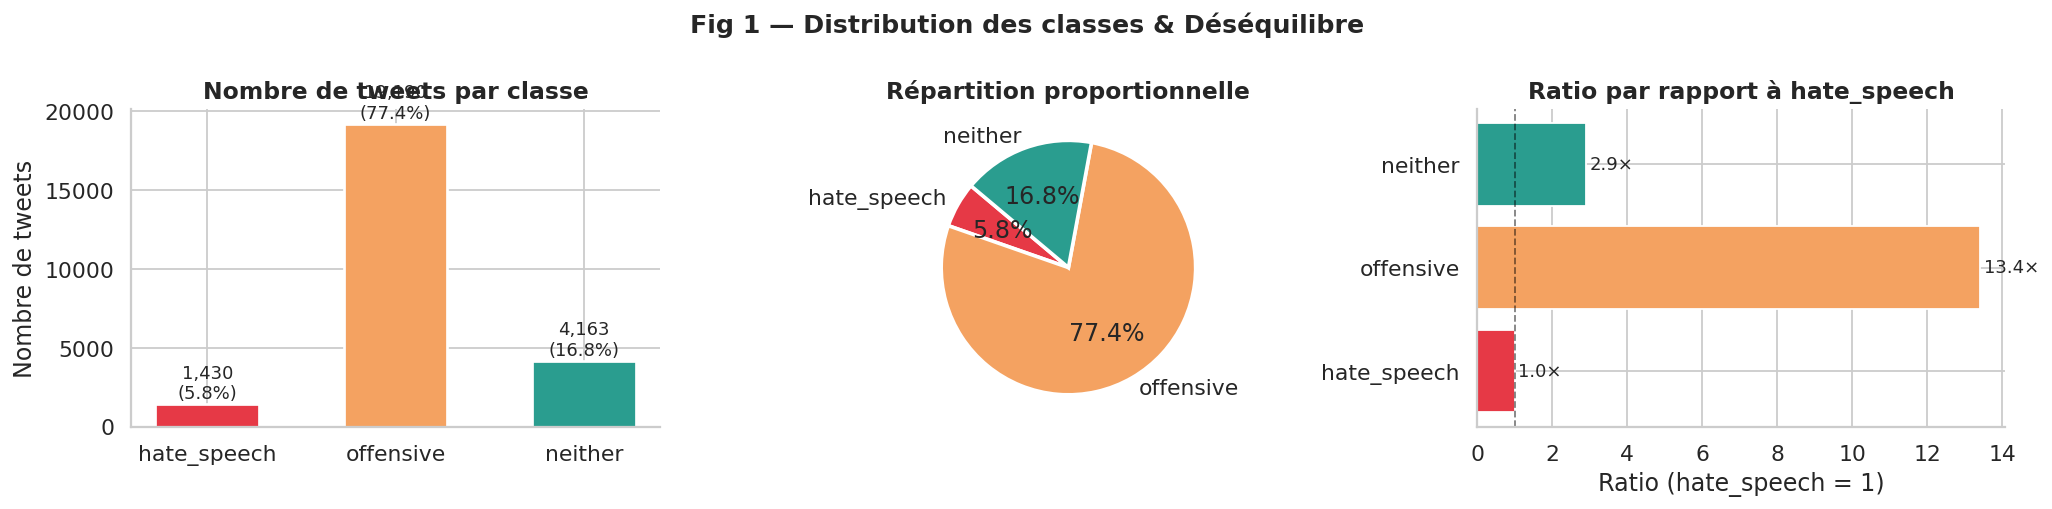

In [14]:
sep('3. DISTRIBUTION DES CLASSES')

counts = df['label'].value_counts().reindex(CLASS_NAMES)
pct    = (counts / len(df) * 100).round(1)

print('Distribution des classes :')
for cls, cnt, p in zip(CLASS_NAMES, counts.values, pct.values):
    bar = '█' * int(p / 2)
    print(f'  {cls:<20} {cnt:>6,}  ({p:>5.1f}%)  {bar}')

imbalance = counts.max() / counts.min()
print(f'\nRatio déséquilibre max/min : {imbalance:.1f}:1')
print(f"Ratio offensive/hate_speech : {counts['offensive']//counts['hate_speech']}:1")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar chart
bars = axes[0].bar(CLASS_NAMES, counts.values, color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
axes[0].set_title('Nombre de tweets par classe')
axes[0].set_ylabel('Nombre de tweets')
for bar, cnt, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{cnt:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=CLASS_NAMES, colors=COLORS,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Répartition proportionnelle')

# Déséquilibre relatif à hate_speech
ratios = counts / counts['hate_speech']
bars2 = axes[2].barh(CLASS_NAMES, ratios.values, color=COLORS, edgecolor='white')
axes[2].set_title('Ratio par rapport à hate_speech')
axes[2].set_xlabel('Ratio (hate_speech = 1)')
axes[2].axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
for bar, r in zip(bars2, ratios.values):
    axes[2].text(r + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{r:.1f}×', va='center', fontsize=10)

plt.suptitle('Fig 1 — Distribution des classes & Déséquilibre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation** : Le dataset est fortement déséquilibré. La classe `offensive` représente ~77% des données contre seulement ~6% pour `hate_speech`. Un ratio de 13:1 entre offensive et hate_speech signifie que **tout modèle ignorant ce déséquilibre prédit systématiquement offensive et obtient 77% d'accuracy sans rien apprendre**.

## 4 · Accord inter-annotateurs


═════════════════════════════════════════════════════════════════
  4. ACCORD INTER-ANNOTATEURS
═════════════════════════════════════════════════════════════════
Distribution de la confidence (accord = max_votes / total_votes) :
count    24783.000
mean         0.905
std          0.149
min          0.444
25%          0.667
50%          1.000
75%          1.000
max          1.000
Name: confidence, dtype: float64

Tweets unanimes (conf=1.0) : 17,482 (70.5%)
Tweets ambigus (conf<0.5)  : 3 (0.0%)
Tweets conf<0.67 (noisy)   : 6,733 (27.2%)

Confidence moyenne par classe :
              mean    std    min  median
label                                   
hate_speech  0.728  0.131  0.444   0.667
neither      0.899  0.153  0.500   1.000
offensive    0.919  0.141  0.444   1.000


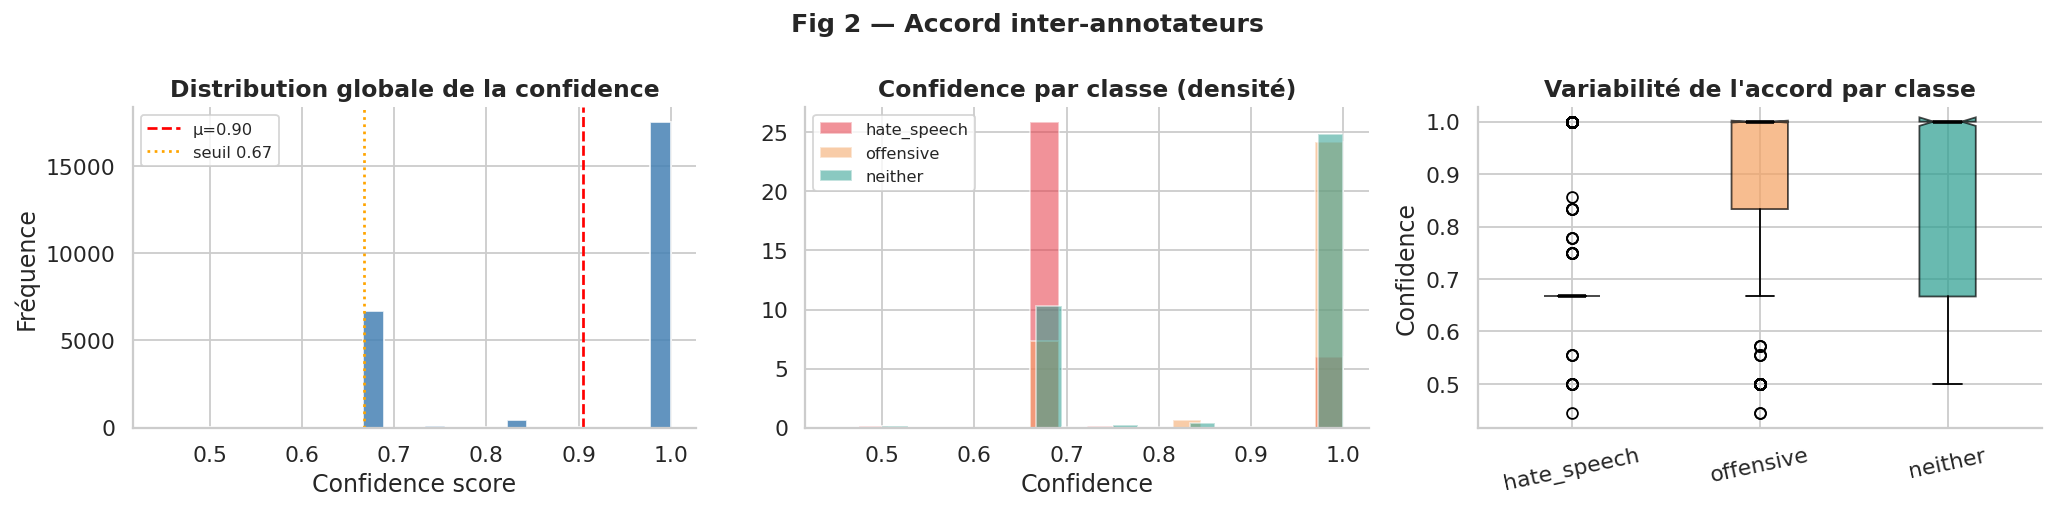

In [15]:
sep('4. ACCORD INTER-ANNOTATEURS')

print('Distribution de la confidence (accord = max_votes / total_votes) :')
print(df['confidence'].describe().round(3))
print(f"\nTweets unanimes (conf=1.0) : {(df['confidence']==1.0).sum():,} ({(df['confidence']==1.0).mean():.1%})")
print(f"Tweets ambigus (conf<0.5)  : {(df['confidence']<0.5).sum():,} ({(df['confidence']<0.5).mean():.1%})")
print(f"Tweets conf<0.67 (noisy)   : {(df['confidence']<0.667).sum():,} ({(df['confidence']<0.667).mean():.1%})")

print('\nConfidence moyenne par classe :')
print(df.groupby('label')['confidence'].agg(['mean','std','min','median']).round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme global
axes[0].hist(df['confidence'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['confidence'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"μ={df['confidence'].mean():.2f}")
axes[0].axvline(0.667, color='orange', linestyle=':', linewidth=1.5, label='seuil 0.67')
axes[0].set_title('Distribution globale de la confidence')
axes[0].set_xlabel('Confidence score')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=9)

# Par classe
for lbl, col in zip(CLASS_NAMES, COLORS):
    axes[1].hist(df.loc[df.label==lbl, 'confidence'], bins=18, alpha=0.55,
                 color=col, label=lbl, density=True)
axes[1].set_title('Confidence par classe (densité)')
axes[1].set_xlabel('Confidence')
axes[1].legend(fontsize=9)

# Boxplot par classe
data_bp = [df[df['label']==c]['confidence'].values for c in CLASS_NAMES]
bp = axes[2].boxplot(data_bp, patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_xticklabels(CLASS_NAMES, rotation=12)
axes[2].set_title('Variabilité de l\'accord par classe')
axes[2].set_ylabel('Confidence')

plt.suptitle('Fig 2 — Accord inter-annotateurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



═════════════════════════════════════════════════════════════════
  4b. NOMBRE D'ANNOTATEURS PAR TWEET
═════════════════════════════════════════════════════════════════
count
3    22807
4      211
6     1571
7       27
9      167


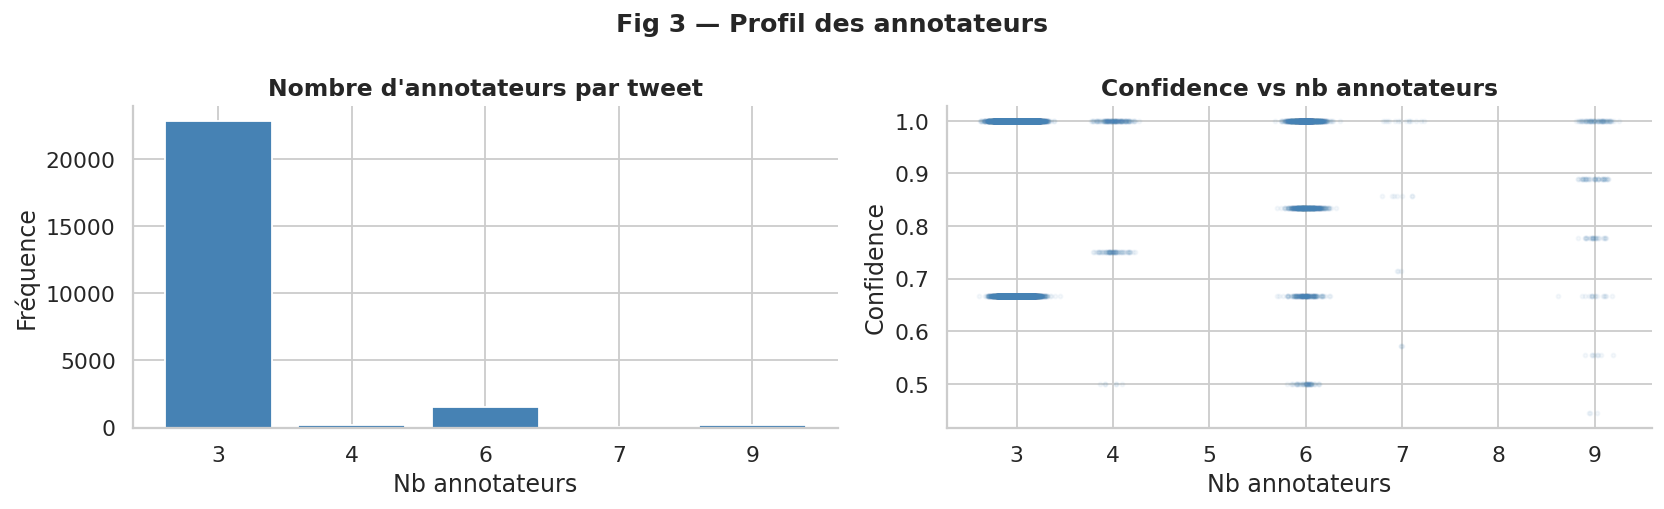

In [16]:
# Distribution du nombre d'annotateurs
sep('4b. NOMBRE D\'ANNOTATEURS PAR TWEET')
print(df['count'].value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = df['count'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
axes[0].set_title('Nombre d\'annotateurs par tweet')
axes[0].set_xlabel('Nb annotateurs')
axes[0].set_ylabel('Fréquence')

# Confidence vs nb annotateurs
axes[1].scatter(df['count'] + np.random.normal(0, 0.1, len(df)),
                df['confidence'], alpha=0.05, s=5, color='steelblue')
axes[1].set_title('Confidence vs nb annotateurs')
axes[1].set_xlabel('Nb annotateurs')
axes[1].set_ylabel('Confidence')

plt.suptitle('Fig 3 — Profil des annotateurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation** : La classe `hate_speech` a la confidence moyenne la plus basse (~73%) vs `offensive` (~92%). **Ces 27% de désaccord sur hate_speech fixent un plafond pratique pour n'importe quel modèle ML** — certaines erreurs ne sont pas des erreurs du modèle mais des désaccords humains.

## 5 · Analyse textuelle (longueur, mots, tokens)


═════════════════════════════════════════════════════════════════
  5. LONGUEUR DES TWEETS PAR CLASSE
═════════════════════════════════════════════════════════════════
Longueur (caractères) par classe :
            tweet_len                                            word_count                                       
                count  mean   std  min   25%   50%    75%    max      count  mean  std  min  25%   50%   75%   max
label                                                                                                             
hate_speech    1430.0  84.6  40.5  5.0  49.0  82.0  121.0  254.0     1430.0  13.9  7.0  1.0  8.0  13.5  20.0  32.0
neither        4163.0  94.9  41.1  7.0  60.0  97.0  132.0  522.0     4163.0  14.9  6.8  1.0  9.0  15.0  20.0  52.0
offensive     19190.0  83.5  41.5  5.0  50.0  78.0  115.0  754.0    19190.0  14.0  6.8  1.0  8.0  13.0  19.0  36.0


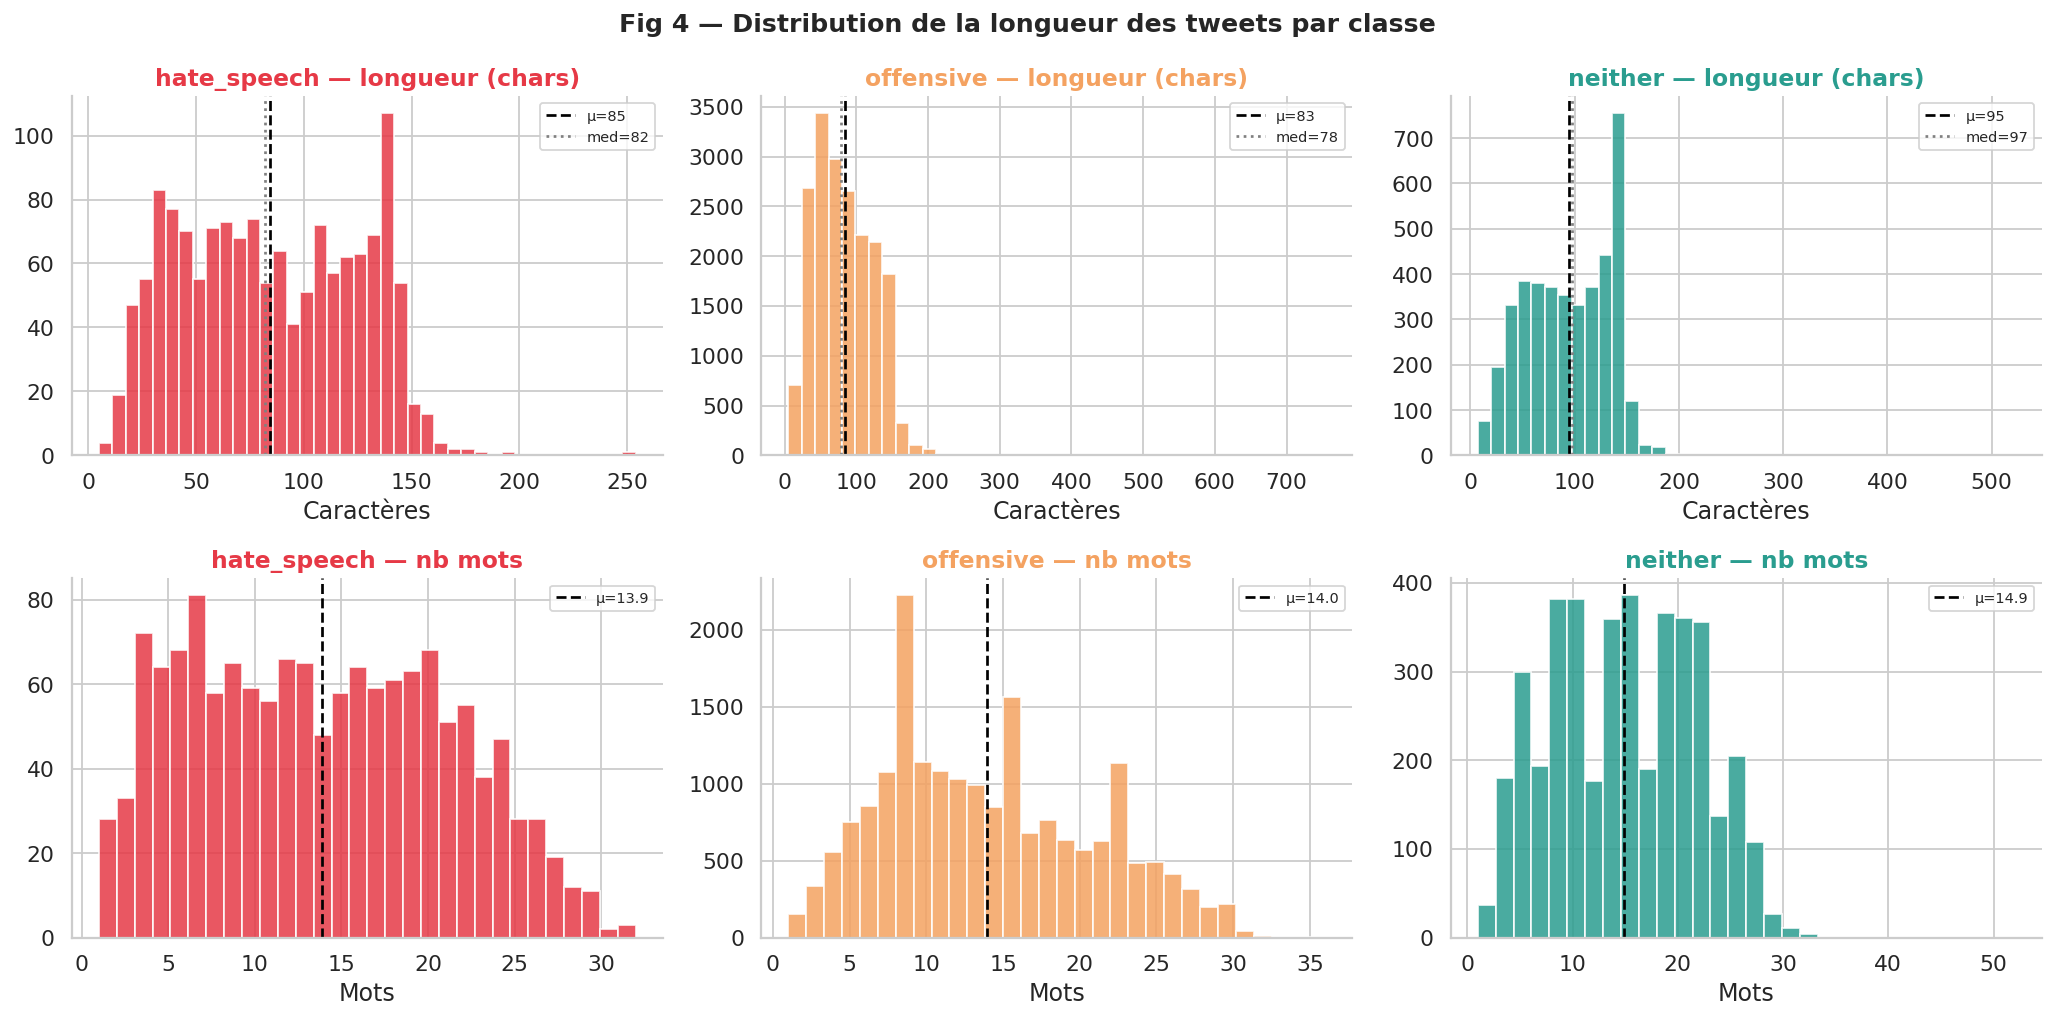

In [17]:
sep('5. LONGUEUR DES TWEETS PAR CLASSE')

print('Longueur (caractères) par classe :')
print(df.groupby('label')[['tweet_len','word_count']].describe().round(1).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    subset_len  = df[df['label']==cls_name]['tweet_len']
    subset_word = df[df['label']==cls_name]['word_count']

    # Distribution longueur en chars
    axes[0,idx].hist(subset_len, bins=40, color=color, alpha=0.85, edgecolor='white')
    axes[0,idx].axvline(subset_len.mean(),   color='black', linestyle='--', lw=1.5, label=f'μ={subset_len.mean():.0f}')
    axes[0,idx].axvline(subset_len.median(), color='grey',  linestyle=':',  lw=1.5, label=f'med={subset_len.median():.0f}')
    axes[0,idx].set_title(f'{cls_name} — longueur (chars)', color=color)
    axes[0,idx].set_xlabel('Caractères')
    axes[0,idx].legend(fontsize=8)

    # Distribution nb mots
    axes[1,idx].hist(subset_word, bins=30, color=color, alpha=0.85, edgecolor='white')
    axes[1,idx].axvline(subset_word.mean(), color='black', linestyle='--', lw=1.5, label=f'μ={subset_word.mean():.1f}')
    axes[1,idx].set_title(f'{cls_name} — nb mots', color=color)
    axes[1,idx].set_xlabel('Mots')
    axes[1,idx].legend(fontsize=8)

plt.suptitle('Fig 4 — Distribution de la longueur des tweets par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



═════════════════════════════════════════════════════════════════
  5b. COMPARAISON BOXPLOTS LONGUEUR
═════════════════════════════════════════════════════════════════


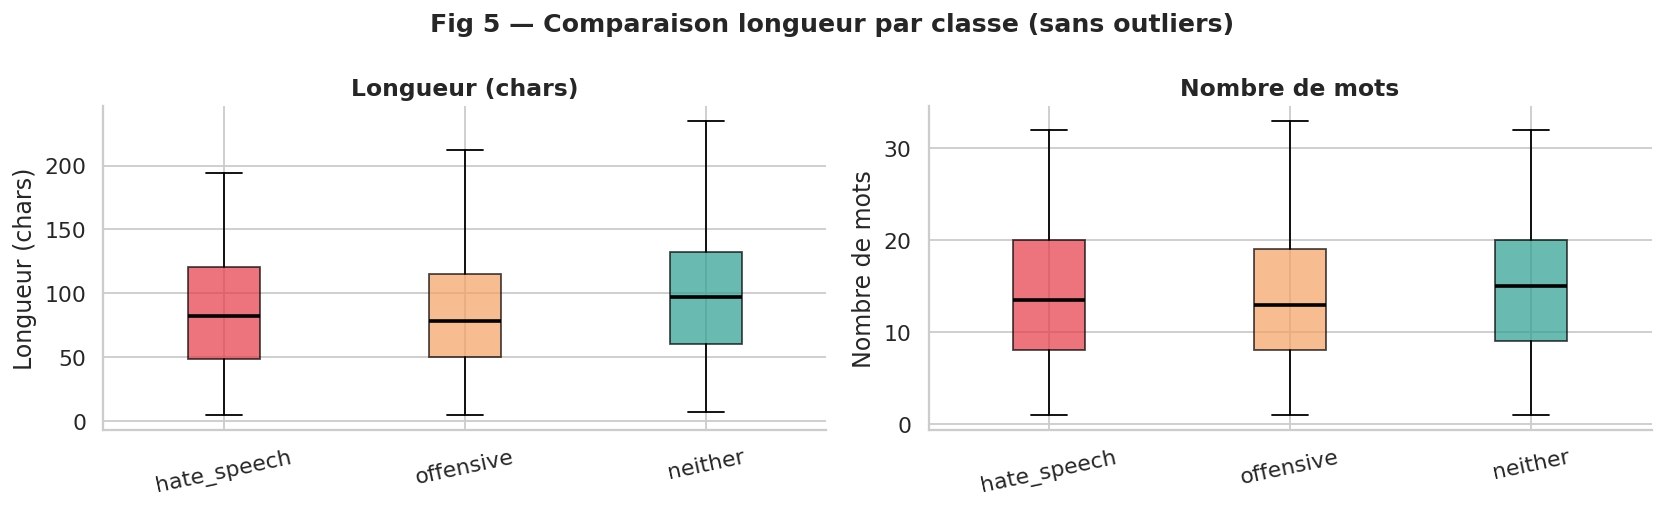


Test Kruskal-Wallis (longueur) : H=300.02, p=7.09e-66
→ Différence statistiquement significative !


In [18]:
sep('5b. COMPARAISON BOXPLOTS LONGUEUR')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, feat, label in [
    (axes[0], 'tweet_len',  'Longueur (chars)'),
    (axes[1], 'word_count', 'Nombre de mots'),
]:
    data = [df[df['label']==c][feat].values for c in CLASS_NAMES]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    showfliers=False)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(CLASS_NAMES, rotation=12)
    ax.set_title(label)
    ax.set_ylabel(label)

plt.suptitle('Fig 5 — Comparaison longueur par classe (sans outliers)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Test statistique (Kruskal-Wallis — non paramétrique)
from scipy.stats import kruskal
groups = [df[df['label']==c]['tweet_len'].values for c in CLASS_NAMES]
stat, p = kruskal(*groups)
print(f'\nTest Kruskal-Wallis (longueur) : H={stat:.2f}, p={p:.2e}')
print('→ Différence statistiquement significative !' if p < 0.05 else '→ Pas de différence significative.')


## 6 · Features stylistiques


═════════════════════════════════════════════════════════════════
  6. FEATURES STYLISTIQUES PAR CLASSE
═════════════════════════════════════════════════════════════════
Moyennes des features stylistiques par classe :


,char_upper,pct_upper,excl_count,question_cnt,mention_cnt,hashtag_cnt,url_cnt,is_retweet
label,,,,,,,,
hate_speech,4.928,0.057,0.177,0.122,0.944,0.483,0.090,0.183
neither,6.987,0.072,0.202,0.124,0.845,0.817,0.245,0.274
offensive,4.751,0.056,0.171,0.098,0.751,0.793,0.103,0.265


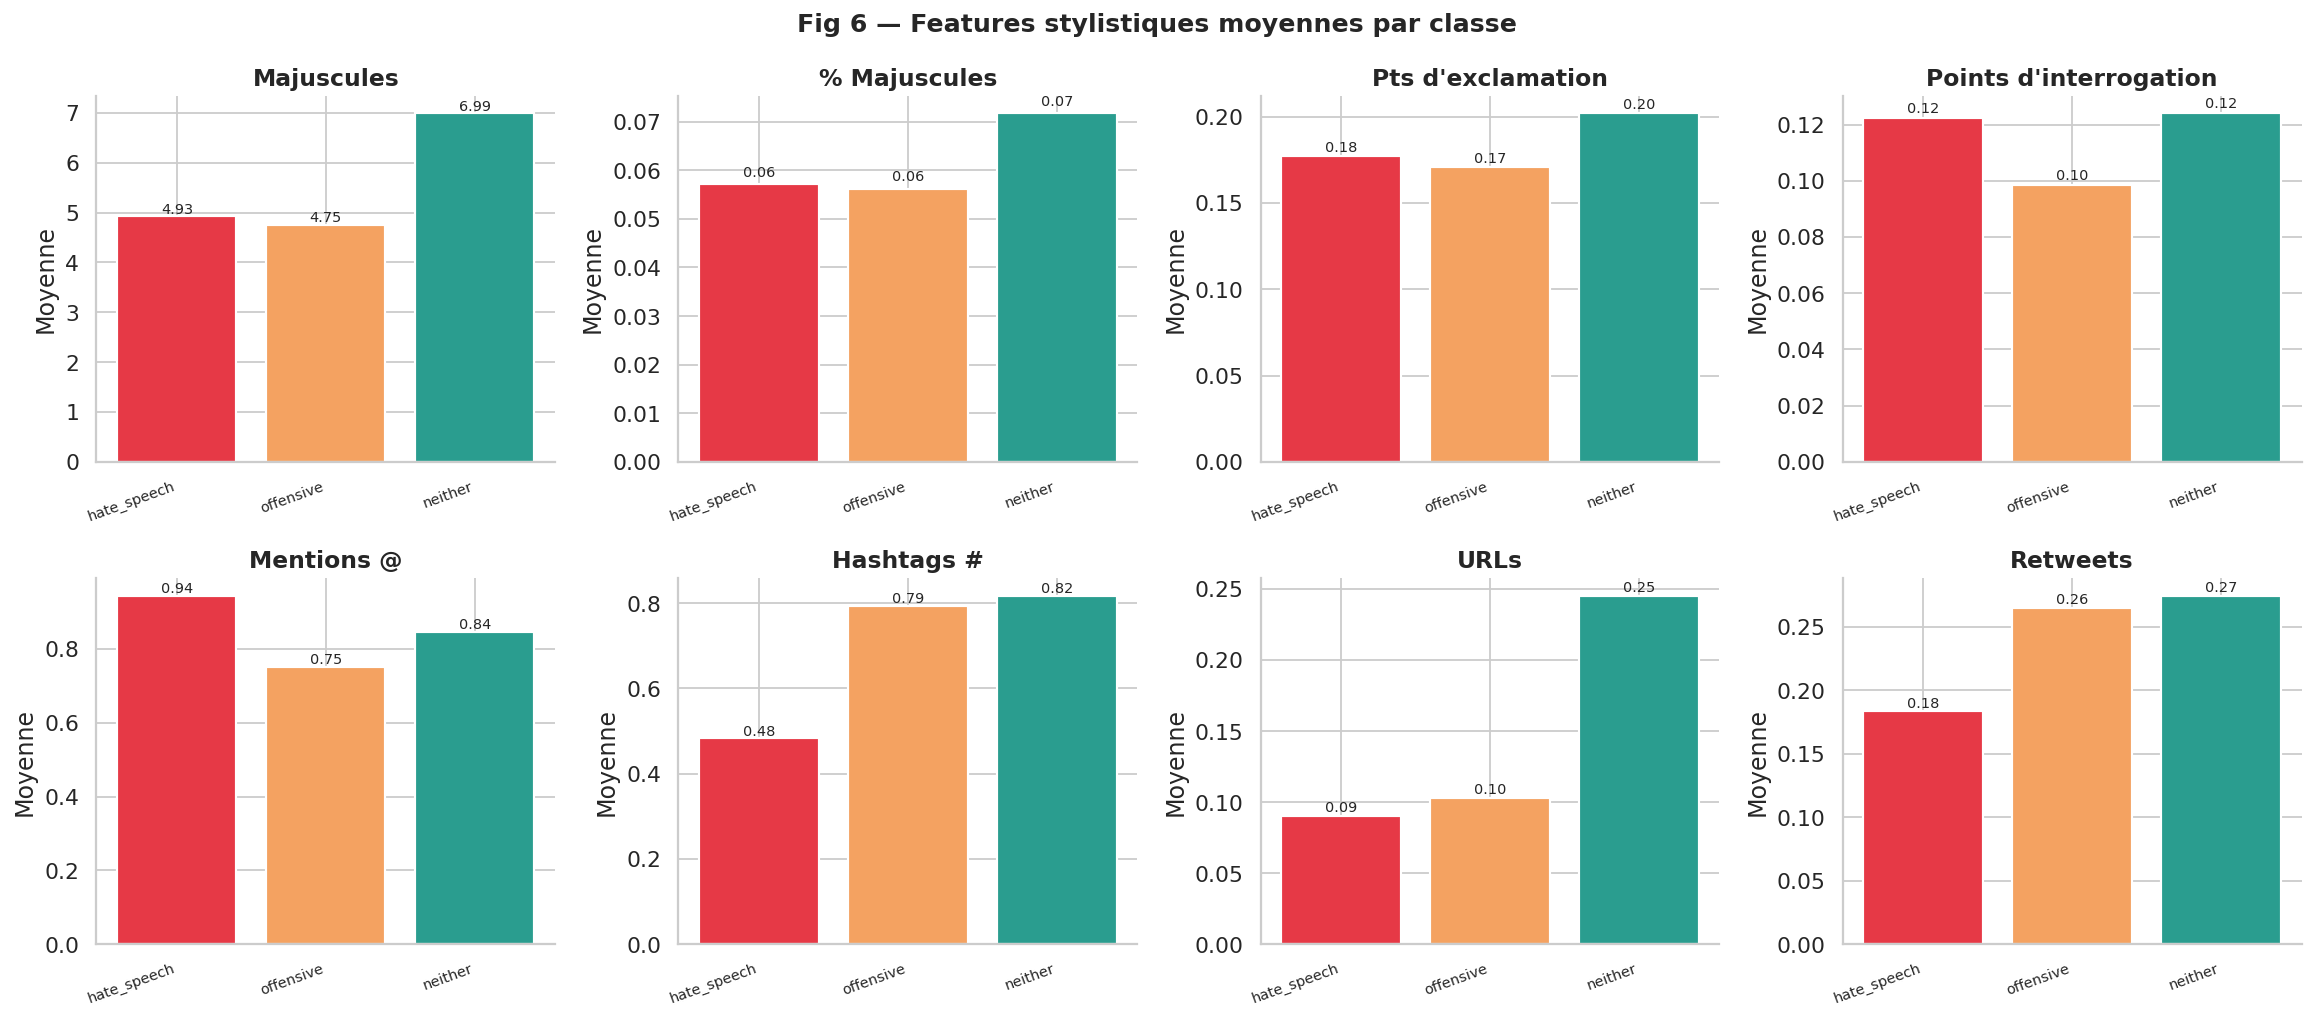

In [19]:
sep('6. FEATURES STYLISTIQUES PAR CLASSE')

# Statistiques par classe
style_features = ['char_upper','pct_upper','excl_count','question_cnt',
                  'mention_cnt','hashtag_cnt','url_cnt','is_retweet']
print('Moyennes des features stylistiques par classe :')
display(df.groupby('label')[style_features].mean().round(3))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

feat_labels = [
    ('char_upper',   'Majuscules'),
    ('pct_upper',    '% Majuscules'),
    ('excl_count',   'Pts d\'exclamation'),
    ('question_cnt', 'Points d\'interrogation'),
    ('mention_cnt',  'Mentions @'),
    ('hashtag_cnt',  'Hashtags #'),
    ('url_cnt',      'URLs'),
    ('is_retweet',   'Retweets'),
]

for ax, (feat, label) in zip(axes, feat_labels):
    means = [df[df['label']==c][feat].mean() for c in CLASS_NAMES]
    bars  = ax.bar(CLASS_NAMES, means, color=COLORS, edgecolor='white', linewidth=1.2)
    ax.set_title(label)
    ax.set_ylabel('Moyenne')
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=8)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{m:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Fig 6 — Features stylistiques moyennes par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



═════════════════════════════════════════════════════════════════
  6b. VIOLINPLOTS DES FEATURES CLÉS
═════════════════════════════════════════════════════════════════


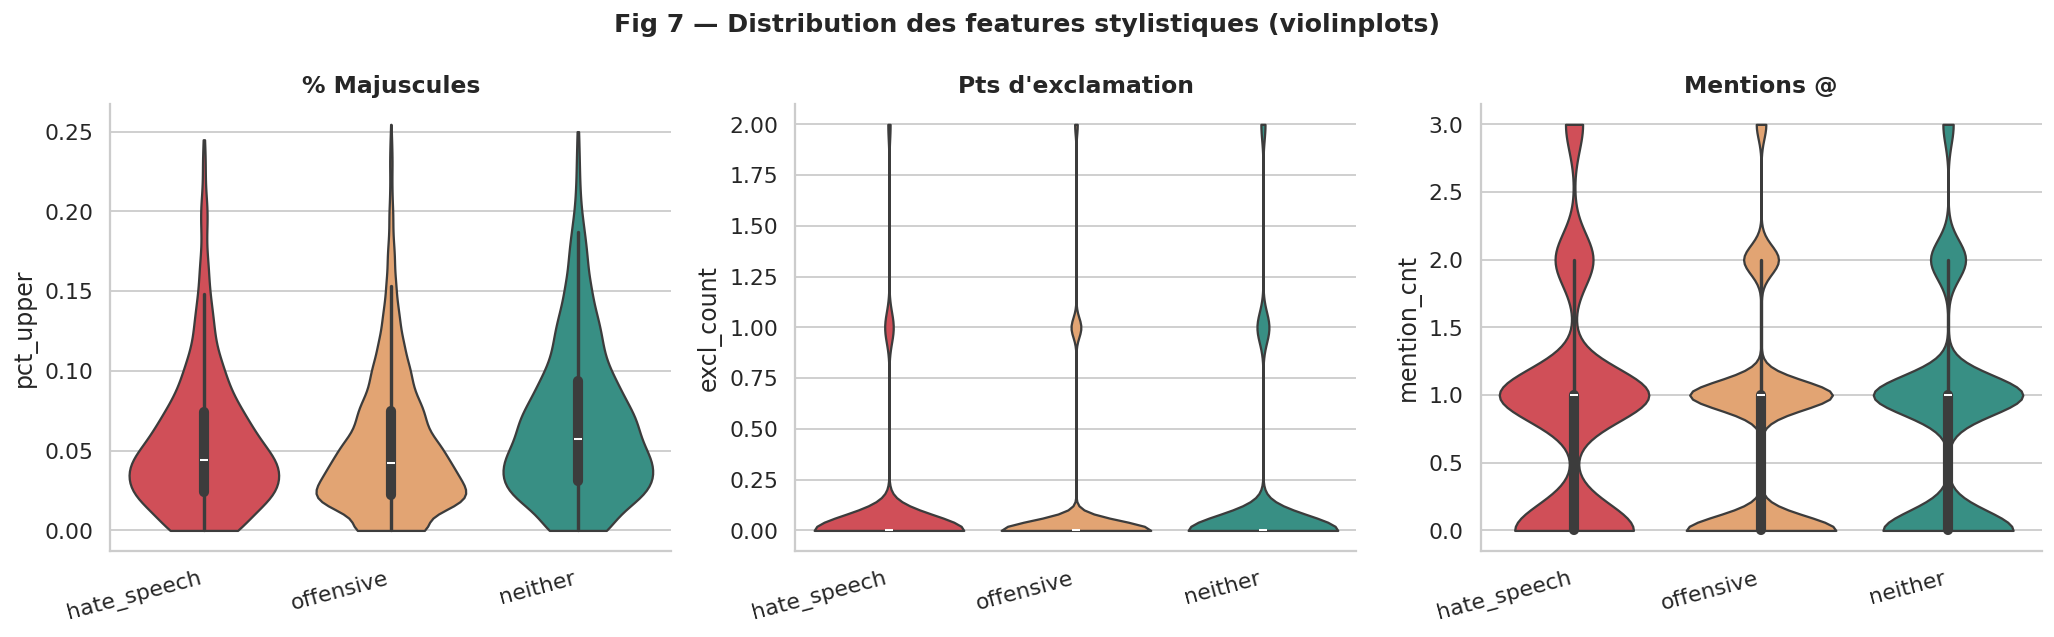

In [20]:
sep('6b. VIOLINPLOTS DES FEATURES CLÉS')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, label in [
    (axes[0], 'pct_upper',  '% Majuscules'),
    (axes[1], 'excl_count', 'Pts d\'exclamation'),
    (axes[2], 'mention_cnt','Mentions @'),
]:
    df_plot = df[df[feat] < df[feat].quantile(0.99)]  # sans outliers extrêmes
    sns.violinplot(data=df_plot, x='label', y=feat, order=CLASS_NAMES,
                   palette=dict(zip(CLASS_NAMES, COLORS)), ax=ax, cut=0)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')

plt.suptitle('Fig 7 — Distribution des features stylistiques (violinplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7 · Vocabulaire & Overlap entre classes


═════════════════════════════════════════════════════════════════
  7. TOP MOTS PAR CLASSE
═════════════════════════════════════════════════════════════════


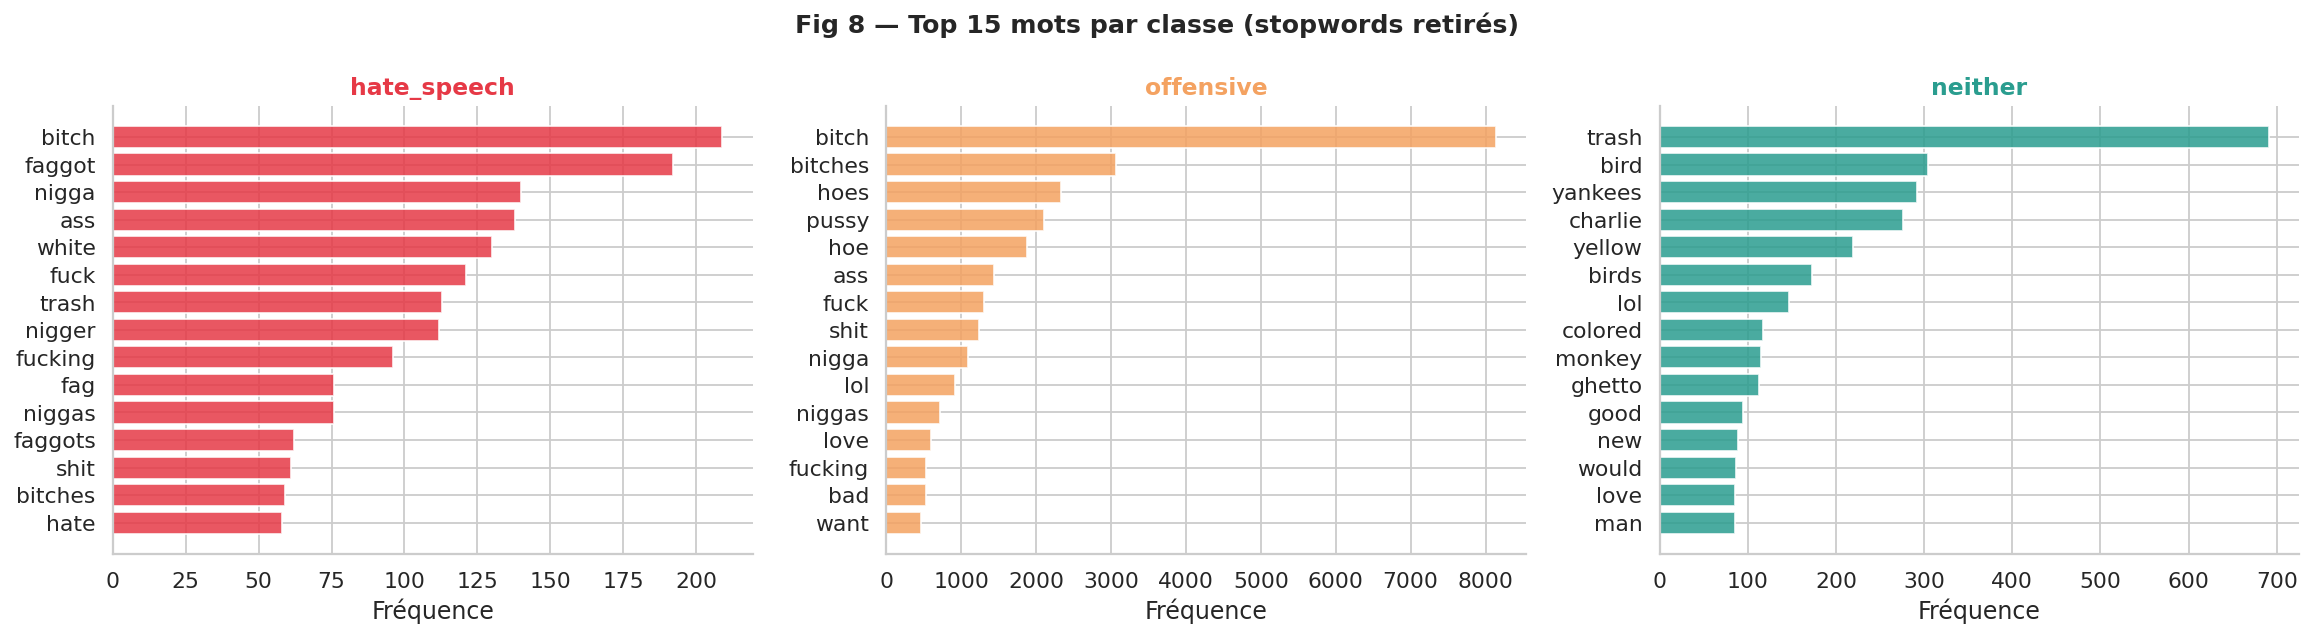

In [21]:
sep('7. TOP MOTS PAR CLASSE')

EXTRA_STOP = STOP | {'like','dont','know','one','get','im','got','people',
                      'said','see','us','say','go','make','think','time'}

def top_words(texts, n=20, stop=EXTRA_STOP):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'[a-zA-Z]+', str(t))
                  if w.lower() not in stop and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    texts  = df[df['label']==cls_name]['tweet'].values
    top    = top_words(texts, n=15)
    words  = [w for w, _ in top]
    counts = [c for _, c in top]
    axes[idx].barh(words[::-1], counts[::-1], color=color, alpha=0.85, edgecolor='white')
    axes[idx].set_title(cls_name, color=color)
    axes[idx].set_xlabel('Fréquence')

plt.suptitle('Fig 8 — Top 15 mots par classe (stopwords retirés)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



═════════════════════════════════════════════════════════════════
  7b. OVERLAP DE VOCABULAIRE ENTRE CLASSES
═════════════════════════════════════════════════════════════════
Taille du vocabulaire par classe (mots fréquents ≥5 tweets):
  hate_speech         : 373 mots
  offensive           : 3,408 mots
  neither             : 1,251 mots

Mots exclusifs à hate_speech      : 13
Mots exclusifs à offensive        : 2,346
Partagés hate+offensive (pas nei) : 73
Communs aux 3 classes             : 284

Jaccard Index hate_speech ∩ offensive : 10.4%
→ Un overlap élevé explique pourquoi les modèles confondent les deux classes.


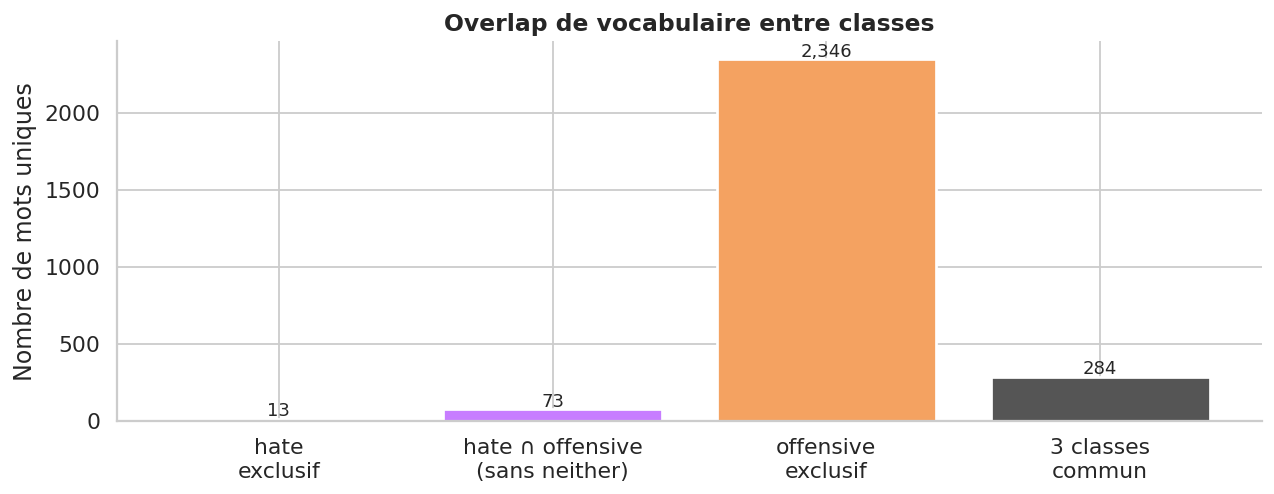

In [22]:
sep('7b. OVERLAP DE VOCABULAIRE ENTRE CLASSES')

# Vocabulaire de chaque classe (mots présents dans au moins 5 tweets)
def get_vocab(texts, min_freq=5):
    words = Counter()
    for t in texts:
        ws = set(w.lower() for w in re.findall(r'[a-zA-Z]+', str(t))
                 if w.lower() not in EXTRA_STOP and len(w) > 2)
        words.update(ws)
    return {w for w, c in words.items() if c >= min_freq}

vocabs = {c: get_vocab(df[df['label']==c]['tweet'].values) for c in CLASS_NAMES}

print('Taille du vocabulaire par classe (mots fréquents ≥5 tweets):')
for c, v in vocabs.items():
    print(f'  {c:<20}: {len(v):,} mots')

# Overlaps
hs, off, nei = vocabs['hate_speech'], vocabs['offensive'], vocabs['neither']
hs_off_only  = hs & off - nei
hs_only      = hs - off - nei
off_only     = off - hs - nei
all_three    = hs & off & nei

print(f'\nMots exclusifs à hate_speech      : {len(hs_only):,}')
print(f'Mots exclusifs à offensive        : {len(off_only):,}')
print(f'Partagés hate+offensive (pas nei) : {len(hs_off_only):,}')
print(f'Communs aux 3 classes             : {len(all_three):,}')
overlap_pct = len(hs & off) / len(hs | off) * 100
print(f'\nJaccard Index hate_speech ∩ offensive : {overlap_pct:.1f}%')
print('→ Un overlap élevé explique pourquoi les modèles confondent les deux classes.')

# Diagramme de Venn (approché avec barres)
fig, ax = plt.subplots(figsize=(10, 4))
categories = [
    ('hate\nexclusif', len(hs_only), COLORS[0]),
    ('hate ∩ offensive\n(sans neither)', len(hs_off_only), '#C77DFF'),
    ('offensive\nexclusif', len(off_only), COLORS[1]),
    ('3 classes\ncommun', len(all_three), '#555'),
]
labels = [c[0] for c in categories]
values = [c[1] for c in categories]
colors = [c[2] for c in categories]
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title('Overlap de vocabulaire entre classes', fontweight='bold')
ax.set_ylabel('Nombre de mots uniques')
plt.tight_layout()
plt.show()



═════════════════════════════════════════════════════════════════
  7c. MOTS DISCRIMINANTS (TF-IDF PAR CLASSE)
═════════════════════════════════════════════════════════════════


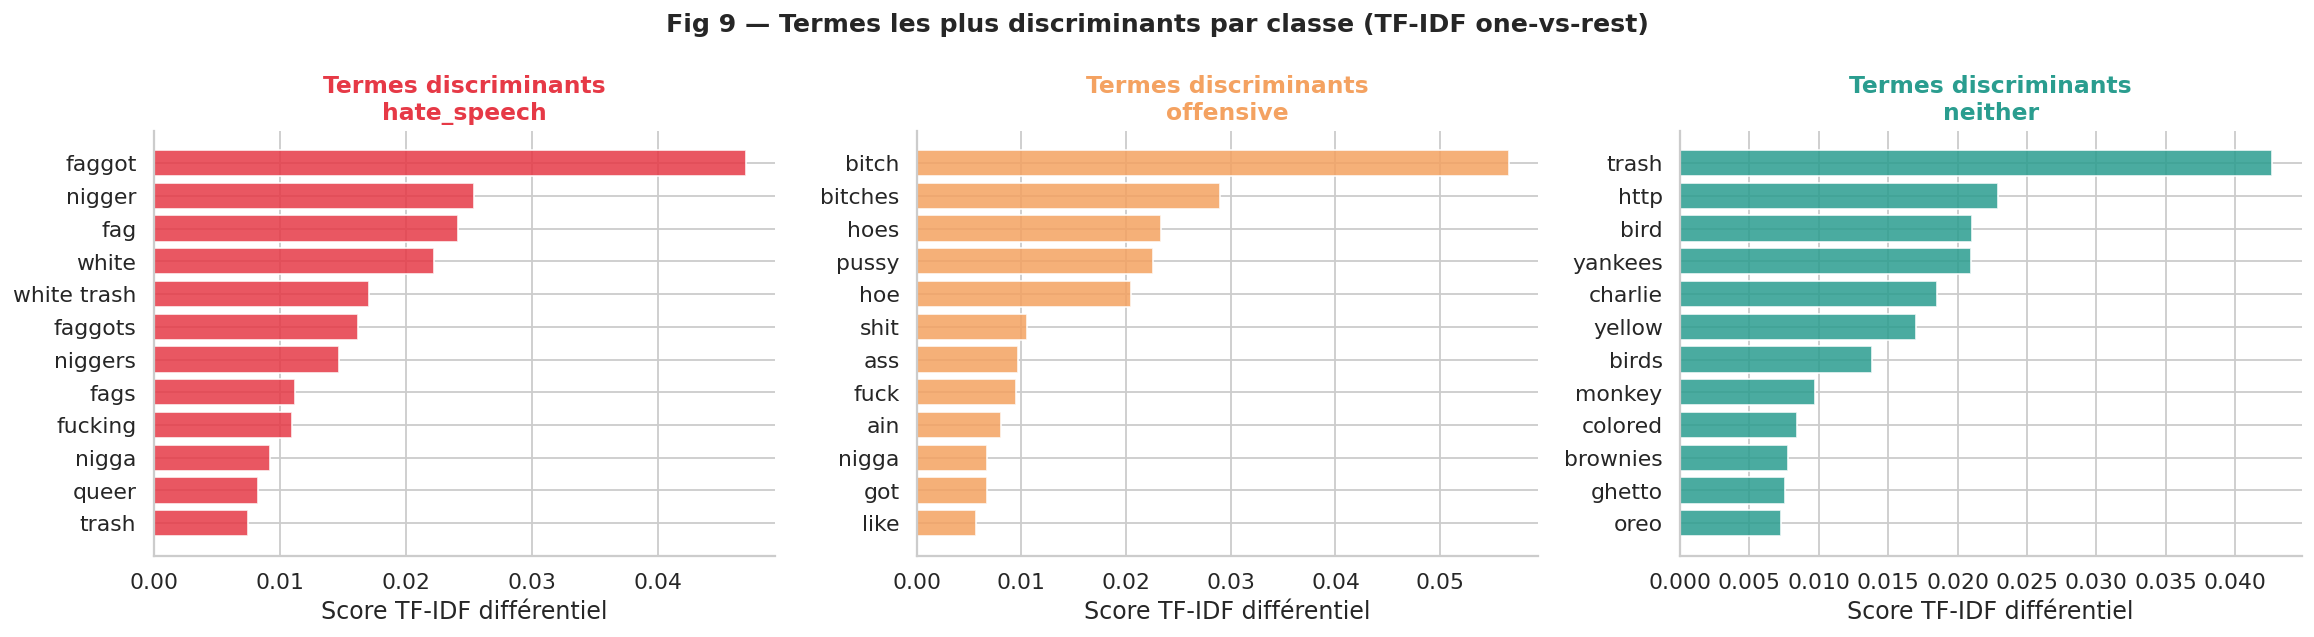

In [24]:
sep('7c. MOTS DISCRIMINANTS (TF-IDF PAR CLASSE)')

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# TF-IDF par classe — style "one-vs-rest"
def top_tfidf_words(df, class_name, n=10):
    texts = df['tweet'].str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)
    mask  = (df['label'] == class_name).astype(int)
    vec   = TfidfVectorizer(max_features=10000, stop_words='english',
                             ngram_range=(1,2), min_df=5, sublinear_tf=True)
    X = vec.fit_transform(texts)
    # Score moyen TF-IDF dans la classe vs hors classe
    score_in  = np.asarray(X[(mask==1).values].mean(axis=0)).flatten()
    score_out = np.asarray(X[(mask==0).values].mean(axis=0)).flatten()
    diff = score_in - score_out
    idx  = np.argsort(diff)[::-1][:n]
    feats = np.array(vec.get_feature_names_out())
    return list(zip(feats[idx], diff[idx]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cls_name, color) in zip(axes, zip(CLASS_NAMES, COLORS)):
    top = top_tfidf_words(df, cls_name, n=12)
    words = [w for w, _ in top]
    scores = [s for _, s in top]
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Termes discriminants\n{cls_name}', color=color)
    ax.set_xlabel('Score TF-IDF différentiel')

plt.suptitle('Fig 9 — Termes les plus discriminants par classe (TF-IDF one-vs-rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 · WordClouds par classe


═════════════════════════════════════════════════════════════════
  8. WORDCLOUDS PAR CLASSE
═════════════════════════════════════════════════════════════════


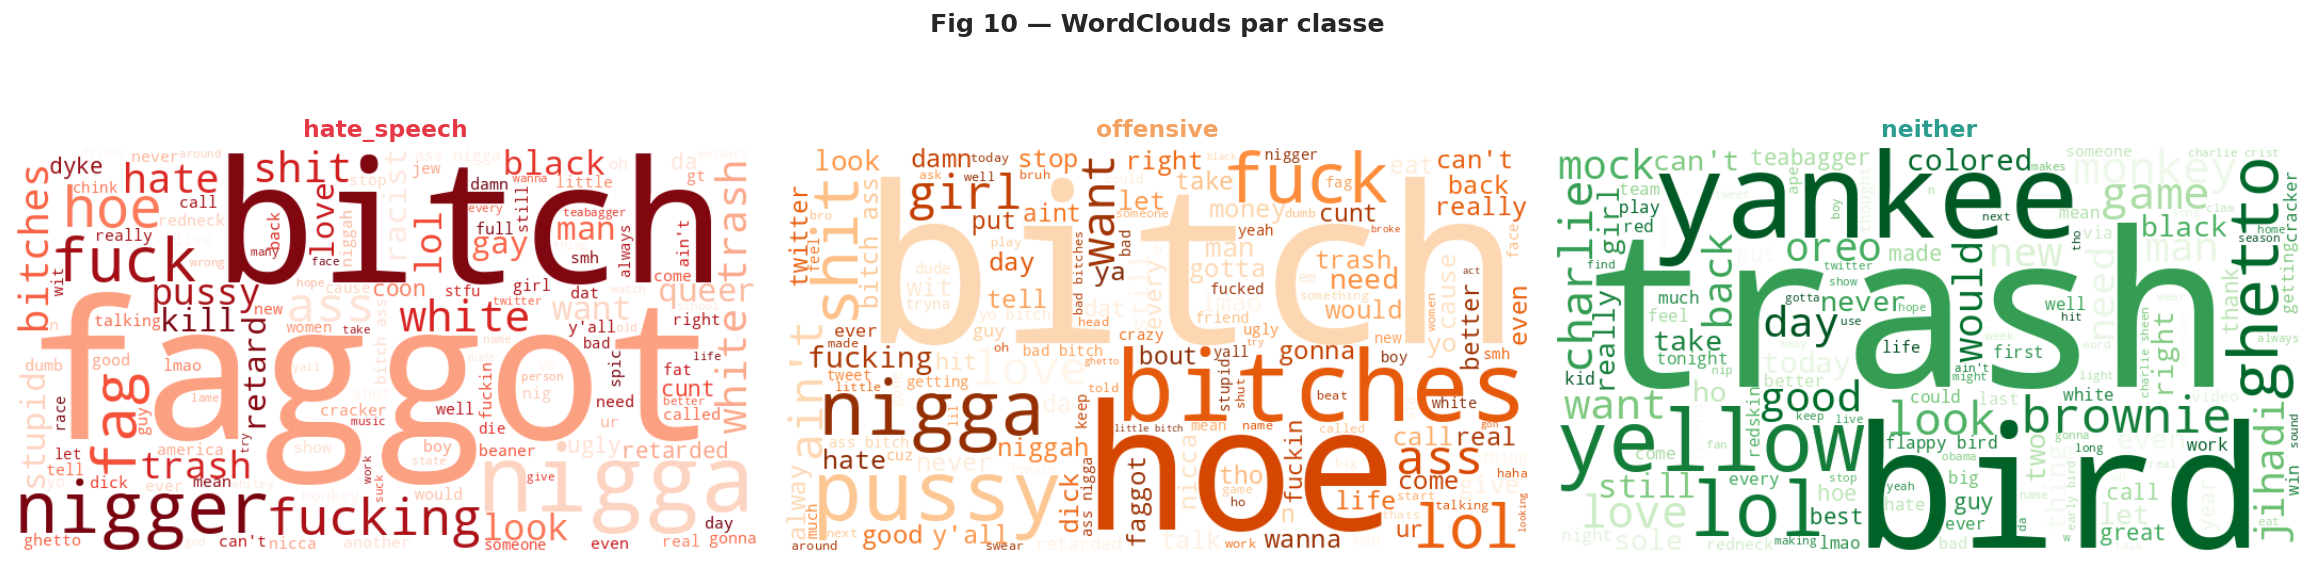

In [25]:
sep('8. WORDCLOUDS PAR CLASSE')

WC_STOP = EXTRA_STOP | {'people','one','dont','know','like','see','say',
                         'make','got','get','going','way'}

CMAPS = ['Reds', 'Oranges', 'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (cls_name, color, cmap) in enumerate(zip(CLASS_NAMES, COLORS, CMAPS)):
    corpus = ' '.join(df[df['label']==cls_name]['tweet'].str.lower().values)
    wc = WordCloud(
        width=700, height=380, background_color='white',
        stopwords=WC_STOP, colormap=cmap, max_words=150,
        collocations=True, min_font_size=8
    ).generate(corpus)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(cls_name, color=color, fontsize=13, fontweight='bold')

plt.suptitle('Fig 10 — WordClouds par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9 · N-grammes discriminants


═════════════════════════════════════════════════════════════════
  9. N-GRAMMES DISCRIMINANTS
═════════════════════════════════════════════════════════════════


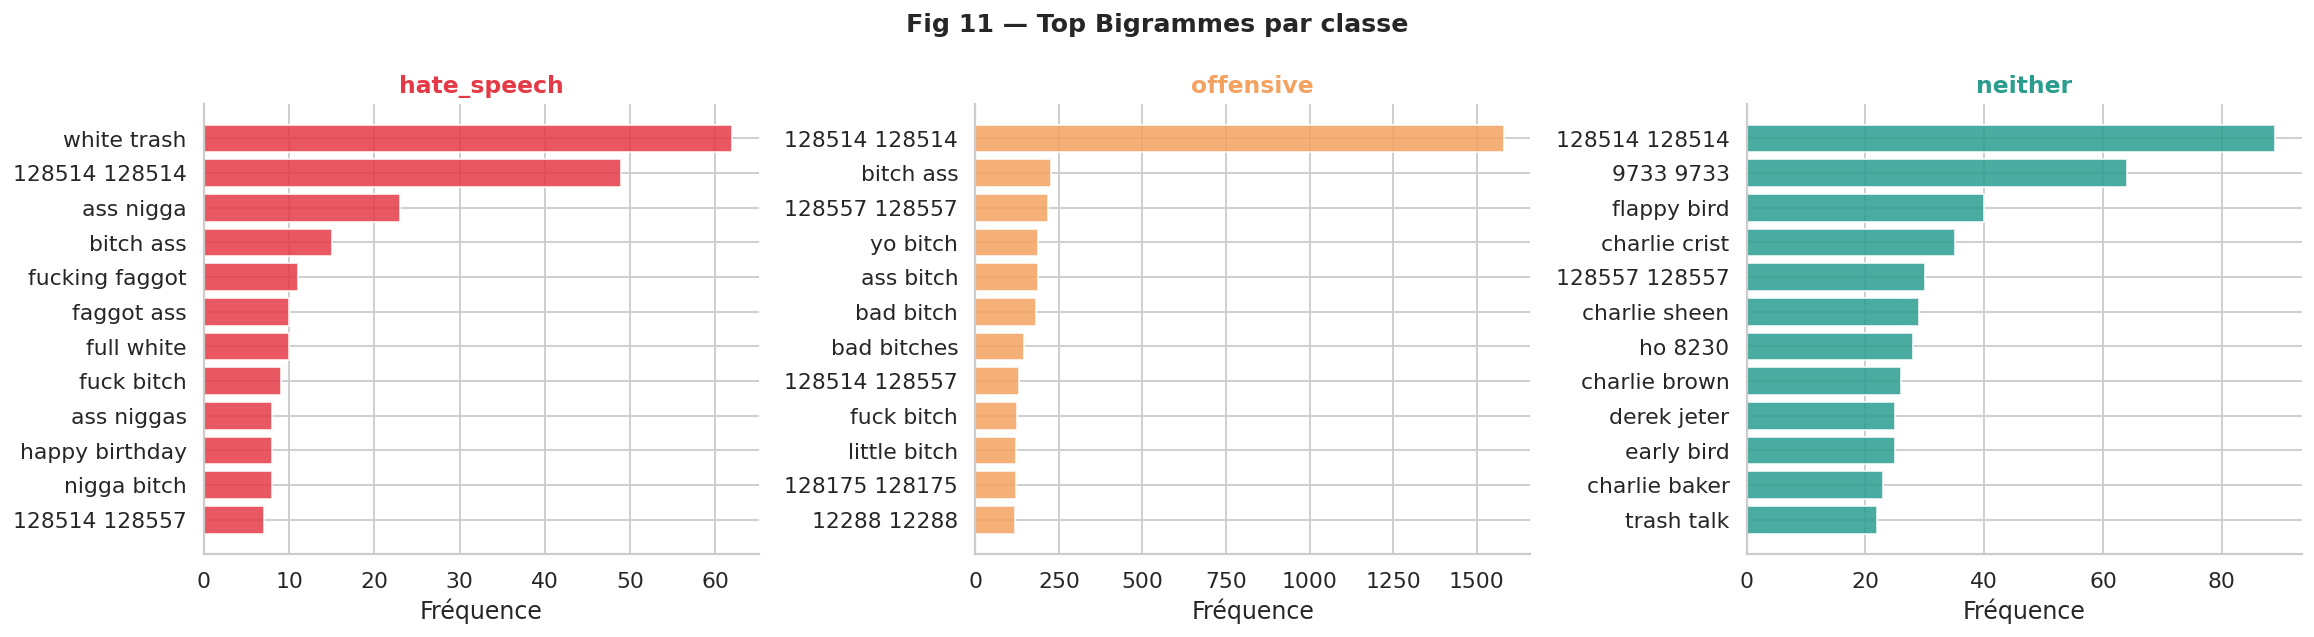

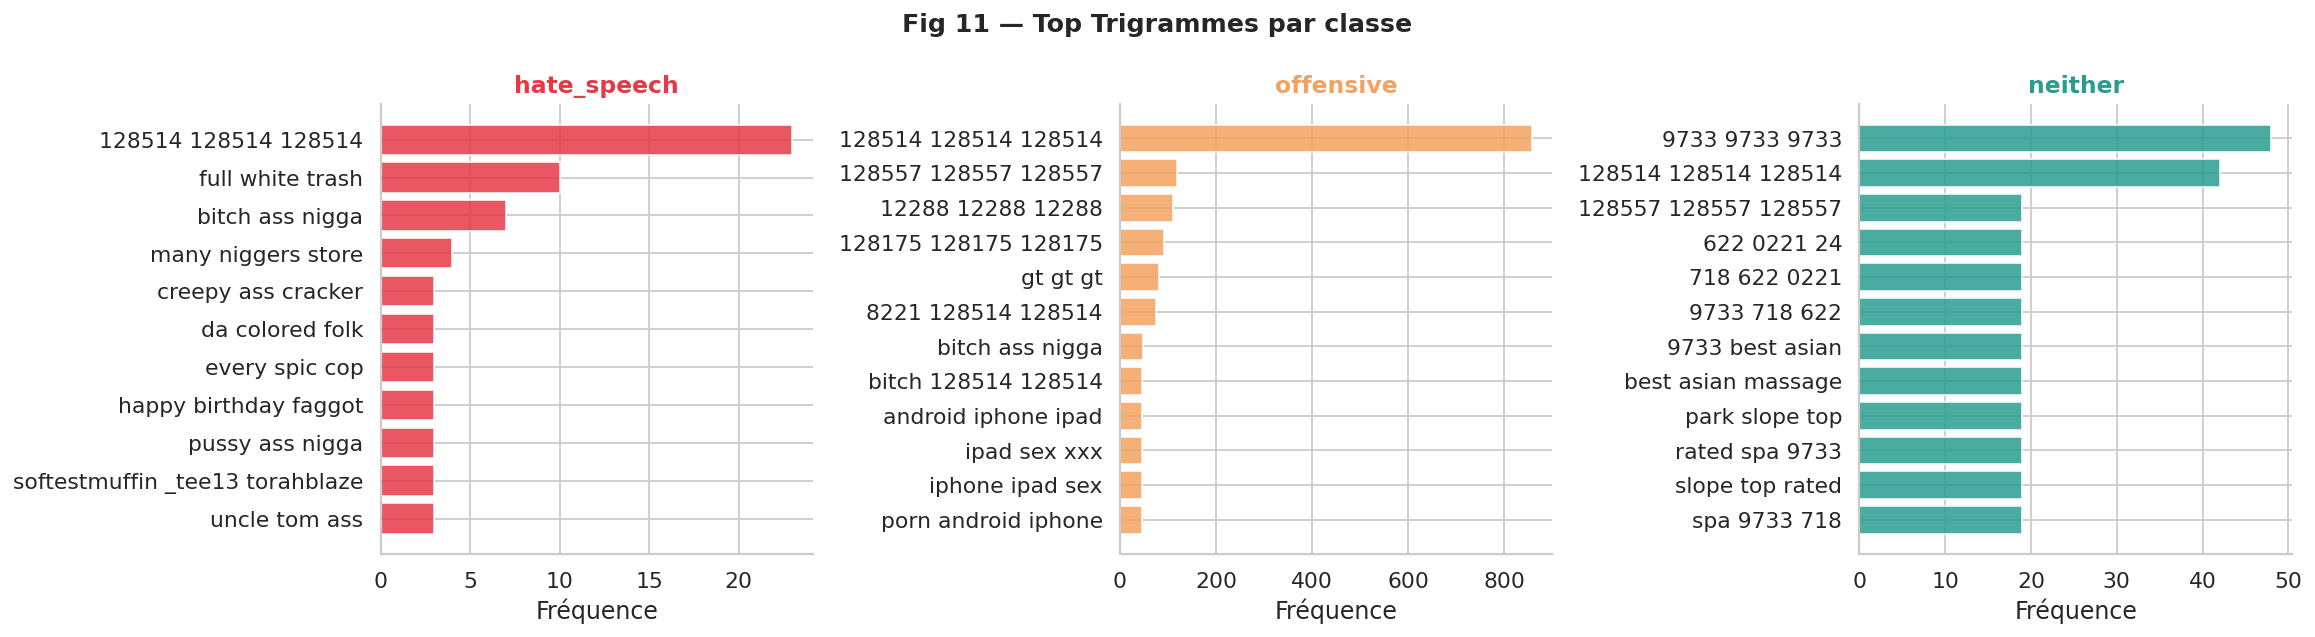

In [27]:
sep('9. N-GRAMMES DISCRIMINANTS')

def top_ngrams(texts, n=2, top_n=15, stop=EXTRA_STOP):
    """Extraire les n-grammes les plus fréquents pour un ensemble de textes."""
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000,
                          stop_words=list(stop), min_df=3)
    X   = vec.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    top   = sorted(zip(terms, freqs), key=lambda x: -x[1])[:top_n]
    return top

for ngram_n, ngram_label in [(2, 'Bigrammes'), (3, 'Trigrammes')]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (cls_name, color) in zip(axes, zip(CLASS_NAMES, COLORS)):
        texts = df[df['label']==cls_name]['tweet'].str.lower().values
        top   = top_ngrams(texts, n=ngram_n, top_n=12)
        words = [w for w, _ in top]
        cnts  = [c for _, c in top]
        ax.barh(words[::-1], cnts[::-1], color=color, alpha=0.85, edgecolor='white')
        ax.set_title(cls_name, color=color)
        ax.set_xlabel('Fréquence')
    plt.suptitle(f'Fig 11 — Top {ngram_label} par classe', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 10 · Analyse des doublons & qualité des données


═════════════════════════════════════════════════════════════════
  10. QUALITÉ DES DONNÉES & DOUBLONS
═════════════════════════════════════════════════════════════════
Doublons exacts (tweet)        : 0 (0.0%)
Tweets ≤ 3 mots (bruit)        : 671 (2.7%)
Tweets ≤ 5 mots                : 2,344 (9.5%)
Tweets = seulement URL/mentions: 0

Tweets ≤ 3 mots par classe :
label
offensive      487
neither        123
hate_speech     61

Tweets identiques avec labels différents : 0


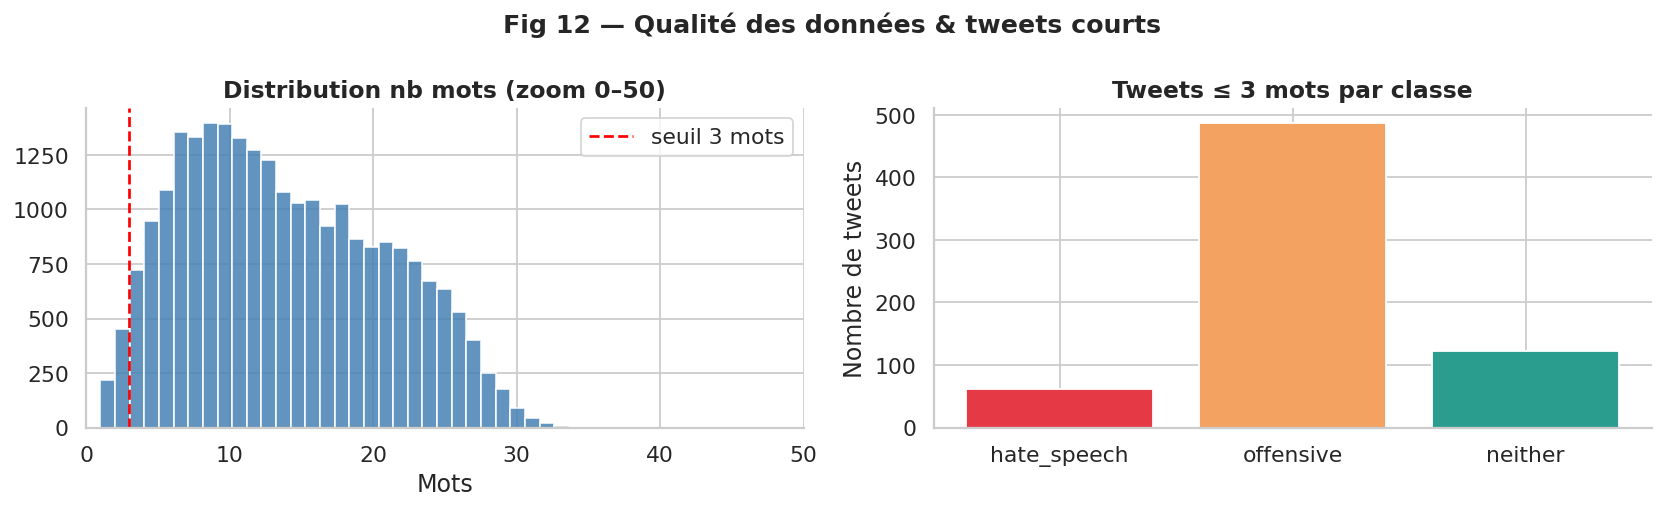

In [28]:
sep('10. QUALITÉ DES DONNÉES & DOUBLONS')

# Doublons textuels exacts
dup_exact = df.duplicated(subset='tweet').sum()
print(f'Doublons exacts (tweet)        : {dup_exact:,} ({dup_exact/len(df):.1%})')

# Tweets très courts (bruit potentiel)
short_3 = (df['word_count'] <= 3).sum()
short_5 = (df['word_count'] <= 5).sum()
print(f'Tweets ≤ 3 mots (bruit)        : {short_3:,} ({short_3/len(df):.1%})')
print(f'Tweets ≤ 5 mots                : {short_5:,} ({short_5/len(df):.1%})')

# Tweets contenant seulement des URLs/mentions
only_url = df[df['tweet'].str.match(r'^\s*(http\S+\s*|@\w+\s*)+$')].shape[0]
print(f'Tweets = seulement URL/mentions: {only_url:,}')

# Distribution de la longueur minimale par classe
print('\nTweets ≤ 3 mots par classe :')
print(df[df['word_count']<=3]['label'].value_counts().to_string())

# Tweets dupliqués avec labels différents
dup_conflicting = df.groupby('tweet')['class'].nunique()
conflicts = (dup_conflicting > 1).sum()
print(f'\nTweets identiques avec labels différents : {conflicts:,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution nb mots — zoom sur les courts
axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(3, color='red', linestyle='--', linewidth=1.5, label='seuil 3 mots')
axes[0].set_xlim(0, 50)
axes[0].set_title('Distribution nb mots (zoom 0–50)')
axes[0].set_xlabel('Mots')
axes[0].legend()

# Tweets vides/courts par classe
short_per_class = {
    c: (df[df['label']==c]['word_count'] <= 3).sum()
    for c in CLASS_NAMES
}
axes[1].bar(short_per_class.keys(), short_per_class.values(), color=COLORS, edgecolor='white')
axes[1].set_title('Tweets ≤ 3 mots par classe')
axes[1].set_ylabel('Nombre de tweets')

plt.suptitle('Fig 12 — Qualité des données & tweets courts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11 · Corrélations entre features


═════════════════════════════════════════════════════════════════
  11. CORRÉLATIONS ENTRE FEATURES NUMÉRIQUES
═════════════════════════════════════════════════════════════════


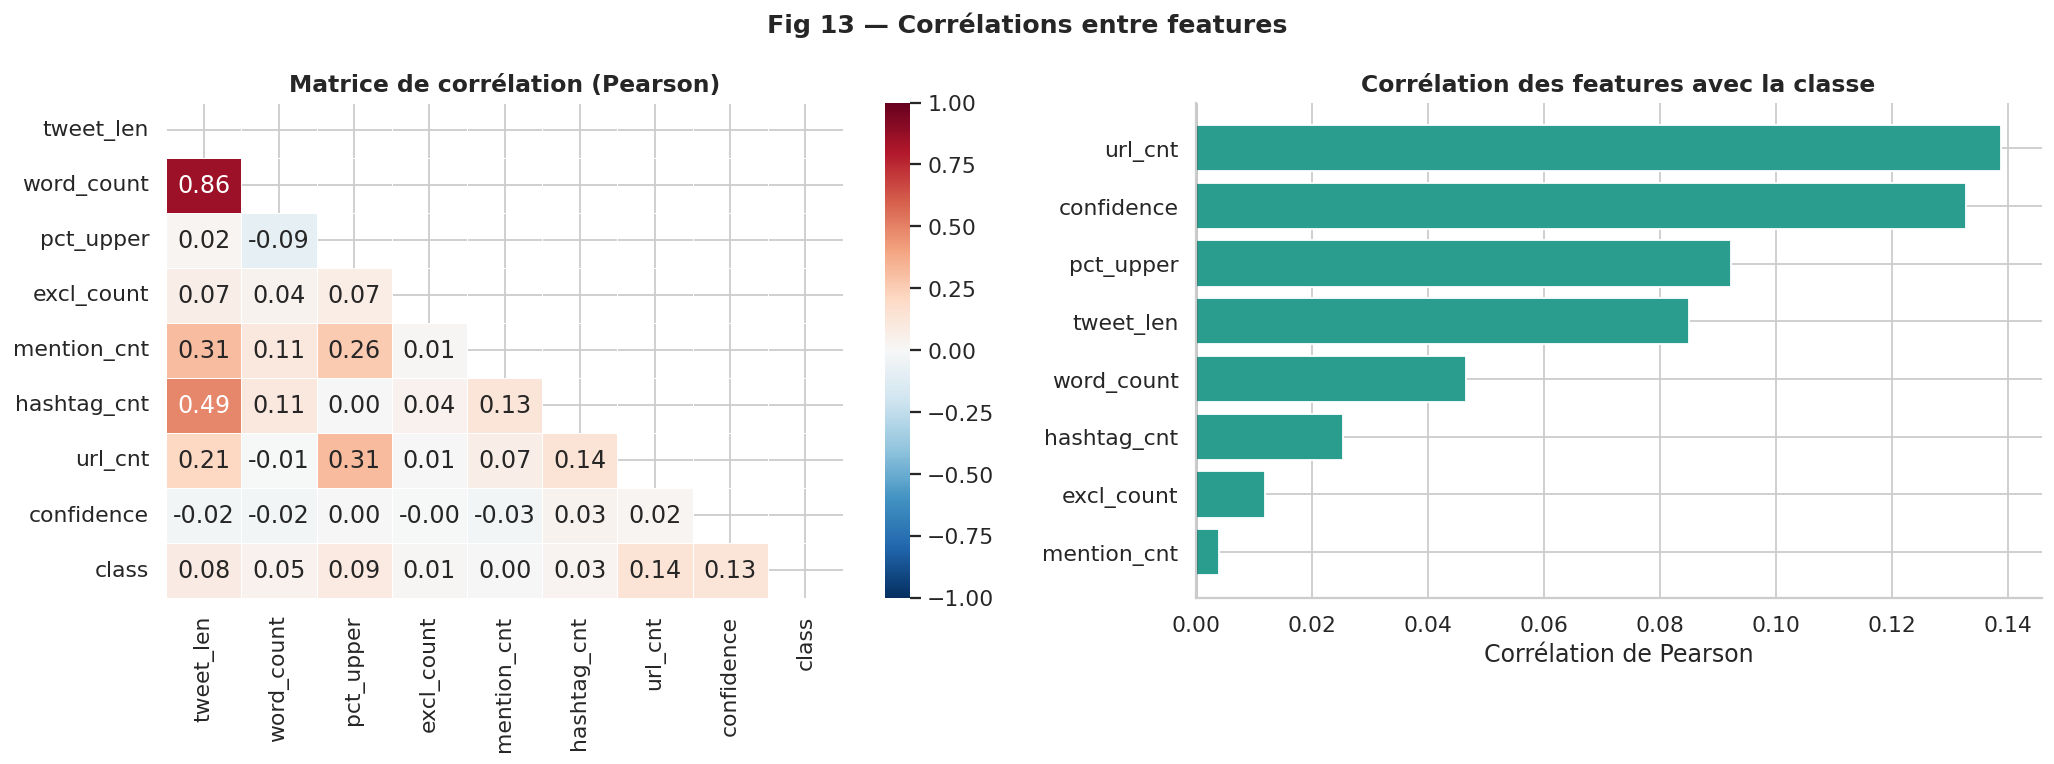


Top corrélations avec la variable cible :
mention_cnt    0.003997
excl_count     0.011945
hashtag_cnt    0.025420
word_count     0.046572
tweet_len      0.084923
pct_upper      0.092156
confidence     0.132799
url_cnt        0.138807


In [29]:
sep('11. CORRÉLATIONS ENTRE FEATURES NUMÉRIQUES')

corr_features = ['tweet_len','word_count','pct_upper','excl_count',
                  'mention_cnt','hashtag_cnt','url_cnt','confidence','class']

corr_matrix = df[corr_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap corrélations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, mask=mask)
axes[0].set_title('Matrice de corrélation (Pearson)')

# Corrélation avec la variable cible (class)
corr_with_target = df[corr_features].corr()['class'].drop('class').sort_values()
colors_bar = ['#E63946' if v < 0 else '#2A9D8F' for v in corr_with_target.values]
axes[1].barh(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation des features avec la classe')
axes[1].set_xlabel('Corrélation de Pearson')

plt.suptitle('Fig 13 — Corrélations entre features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop corrélations avec la variable cible :')
print(corr_with_target.to_string())



═════════════════════════════════════════════════════════════════
  11b. ANALYSE PAR CLASSE — PROFIL MOYEN COMPLET
═════════════════════════════════════════════════════════════════


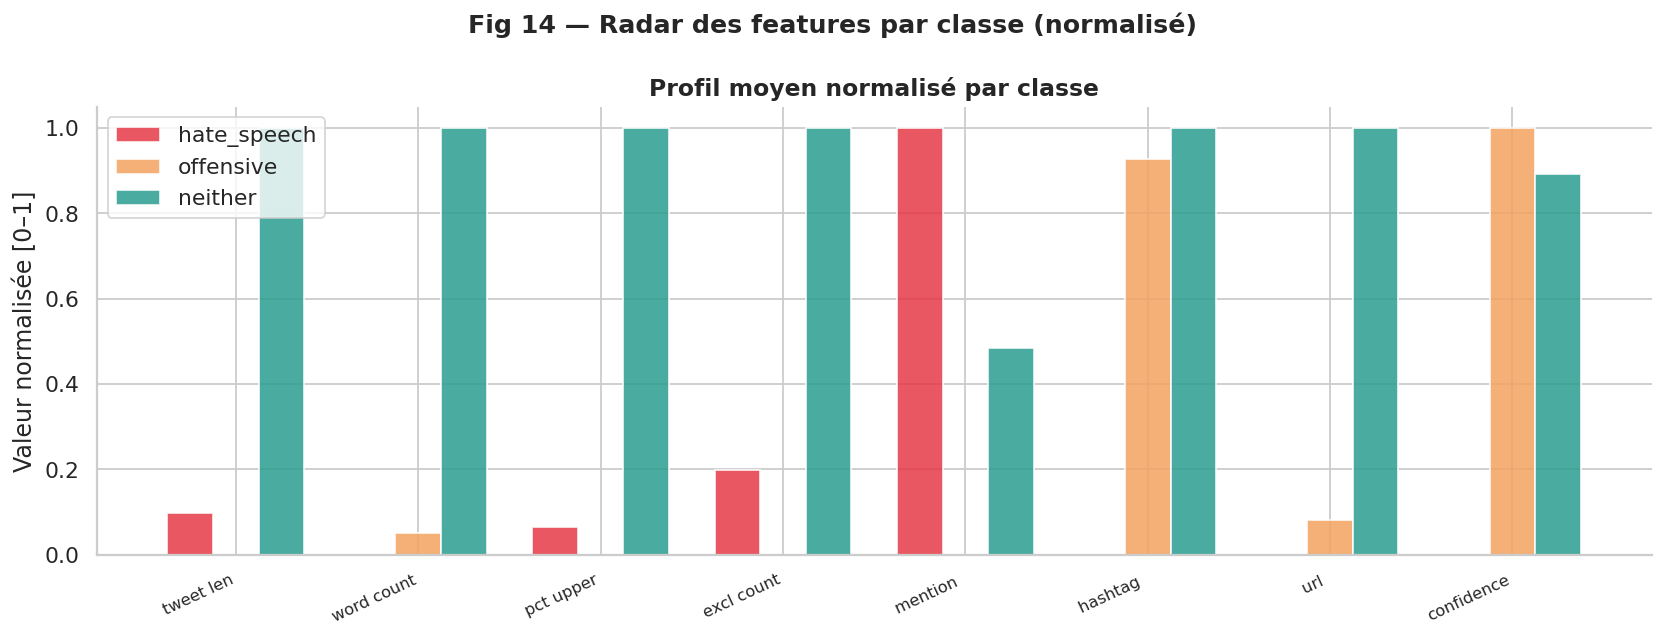

In [30]:
sep('11b. ANALYSE PAR CLASSE — PROFIL MOYEN COMPLET')

profile = df.groupby('label')[corr_features[:-1]].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(corr_features)-1)
width = 0.25

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    vals = profile_norm.loc[cls_name].values
    ax.bar(x + i*width, vals, width, label=cls_name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace('_',' ').replace('cnt','') for c in corr_features[:-1]],
                    rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Valeur normalisée [0–1]')
ax.set_title('Profil moyen normalisé par classe', fontweight='bold')
ax.legend()

plt.suptitle('Fig 14 — Radar des features par classe (normalisé)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12 · Synthèse & Recommandations

In [31]:
sep('12. SYNTHÈSE EDA')

print("""
╔══════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE DES FINDINGS EDA                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DÉSÉQUILIBRE DE CLASSES                                         ║
║  • offensive : 77% des tweets — hate_speech : ~6%               ║
║  • Ratio offensive/hate = 13:1 → risque de modèle biaisé        ║
║  → Stratégie requise : class_weight + confidence weighting       ║
║                                                                  ║
║  ACCORD INTER-ANNOTATEURS                                        ║
║  • hate_speech : conf. moy = 0.73 vs offensive = 0.92           ║
║  • 27% de désaccord sur hate → plafond pratique du modèle        ║
║  → Filtrer les tweets conf < 0.67 réduit le bruit               ║
║                                                                  ║
║  OVERLAP DE VOCABULAIRE                                          ║
║  • hate_speech & offensive partagent ~80%+ du vocabulaire        ║
║  • Signal discriminant = contexte + cibles, pas les mots seuls   ║
║  → Char n-grams (2–5) ciblent les variantes orthographiques      ║
║                                                                  ║
║  FEATURES STYLISTIQUES                                           ║
║  • hate_speech : plus de majuscules, moins de URLs               ║
║  • neither : plus de hashtags et URLs (tweets informationnels)    ║
║  → Ces features ont peu de pouvoir seules mais aident en fusion  ║
║                                                                  ║
║  QUALITÉ DES DONNÉES                                             ║
║  • Peu de doublons exacts, tweets courts répartis uniformément   ║
║  → Nettoyage minimal recommandé (garder les slurs intacts)       ║
║                                                                  ║
║  RECOMMANDATIONS POUR LA MODÉLISATION                           ║
║  1. TF-IDF word (1–2) + char (2–5) comme embedding principal     ║
║  2. class_weight='balanced' + confidence comme sample_weight     ║
║  3. Ne PAS lemmatiser (préserver les slurs)                      ║
║  4. Threshold tuning sur validation set séparé                   ║
║  5. LinearSVC comme modèle de base                               ║
║  6. Plafond attendu hate F1 ≈ 0.45 (bruit de label humain)      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")



═════════════════════════════════════════════════════════════════
  12. SYNTHÈSE EDA
═════════════════════════════════════════════════════════════════

╔══════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE DES FINDINGS EDA                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DÉSÉQUILIBRE DE CLASSES                                         ║
║  • offensive : 77% des tweets — hate_speech : ~6%               ║
║  • Ratio offensive/hate = 13:1 → risque de modèle biaisé        ║
║  → Stratégie requise : class_weight + confidence weighting       ║
║                                                                  ║
║  ACCORD INTER-ANNOTATEURS                                        ║
║  • hate_speech : conf. moy = 0.73 vs offensive = 0.92           ║
║  • 27% de désaccord sur hate → plafond pratique du modèle        ║
║  → Filtrer les tweets


═════════════════════════════════════════════════════════════════
  12b. VISUALISATION FINALE — TABLEAU DE BORD EDA
═════════════════════════════════════════════════════════════════


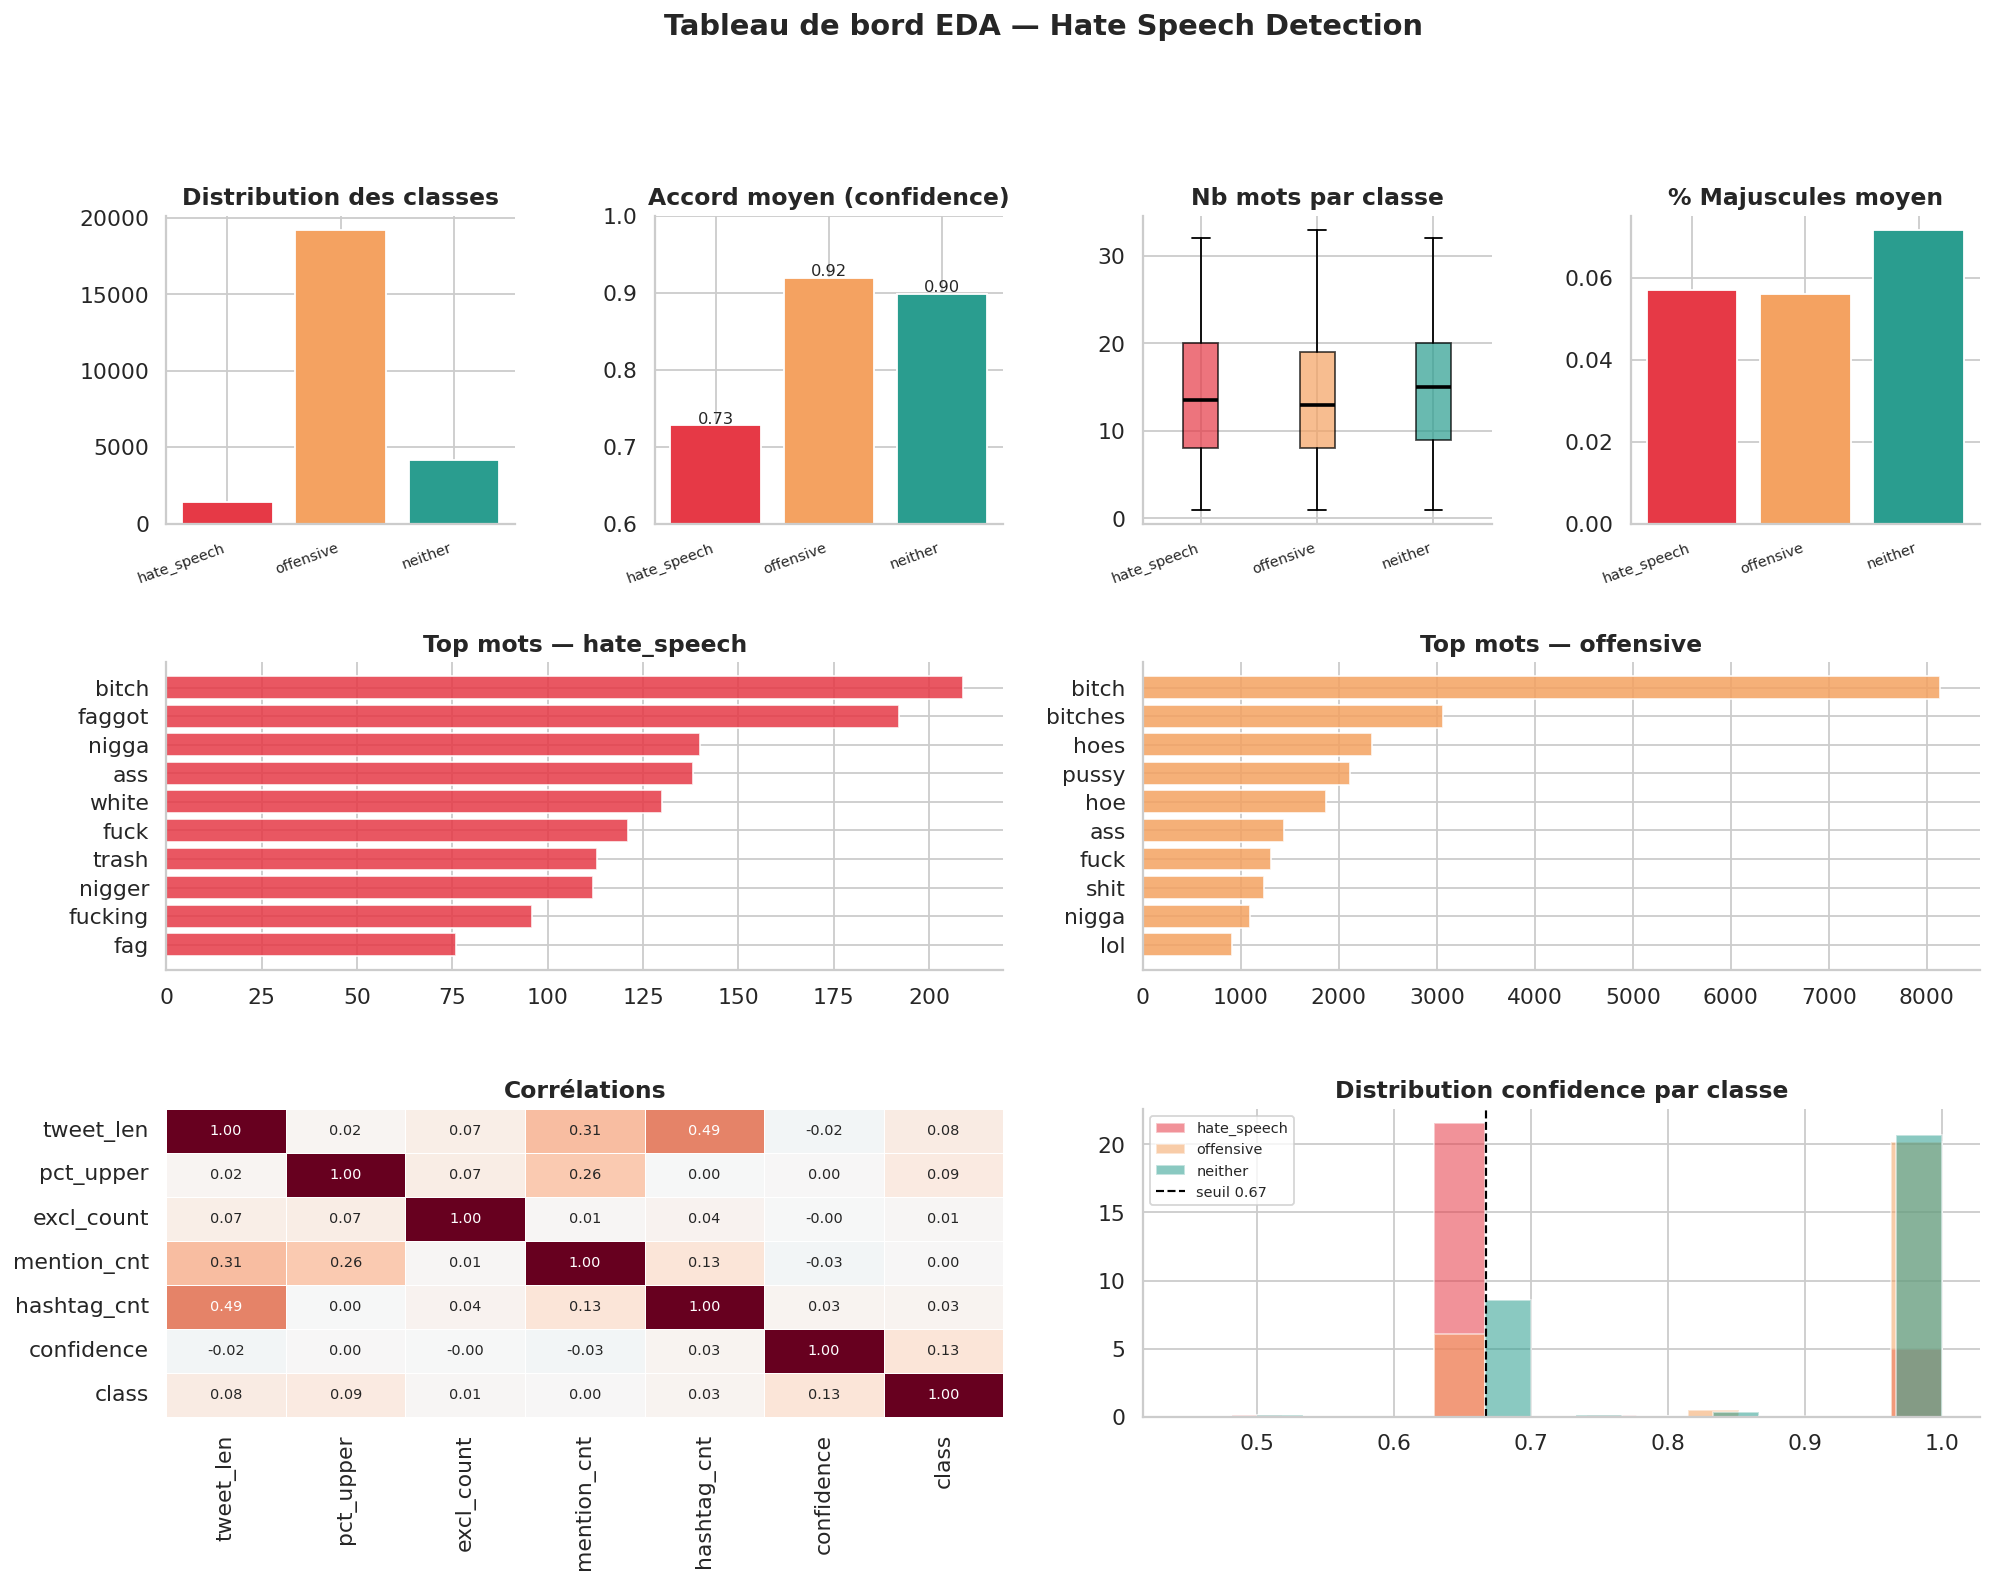

✓ Dashboard sauvegardé → eda_dashboard.png


In [32]:
sep('12b. VISUALISATION FINALE — TABLEAU DE BORD EDA')

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.4)

# 1 — Distribution classes
ax1 = fig.add_subplot(gs[0, 0])
counts = df['label'].value_counts().reindex(CLASS_NAMES)
ax1.bar(CLASS_NAMES, counts.values, color=COLORS, edgecolor='white')
ax1.set_title('Distribution des classes')
ax1.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=8)

# 2 — Confidence par classe
ax2 = fig.add_subplot(gs[0, 1])
means_conf = [df[df['label']==c]['confidence'].mean() for c in CLASS_NAMES]
ax2.bar(CLASS_NAMES, means_conf, color=COLORS, edgecolor='white')
ax2.set_ylim(0.6, 1.0)
ax2.set_title('Accord moyen (confidence)')
ax2.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=8)
for i, (b, v) in enumerate(zip(ax2.patches, means_conf)):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{v:.2f}', ha='center', fontsize=9)

# 3 — Longueur tweets
ax3 = fig.add_subplot(gs[0, 2])
data3 = [df[df['label']==c]['word_count'].values for c in CLASS_NAMES]
bp3 = ax3.boxplot(data3, patch_artist=True, showfliers=False,
                   medianprops=dict(color='black', lw=2))
for patch, color in zip(bp3['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax3.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=8)
ax3.set_title('Nb mots par classe')

# 4 — % Majuscules
ax4 = fig.add_subplot(gs[0, 3])
means_up = [df[df['label']==c]['pct_upper'].mean() for c in CLASS_NAMES]
ax4.bar(CLASS_NAMES, means_up, color=COLORS, edgecolor='white')
ax4.set_title('% Majuscules moyen')
ax4.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=8)

# 5 — Top mots hate_speech
ax5 = fig.add_subplot(gs[1, :2])
top_hs = top_words(df[df['label']=='hate_speech']['tweet'].values, n=10, stop=EXTRA_STOP)
ax5.barh([w for w,_ in top_hs][::-1], [c for _,c in top_hs][::-1],
          color=COLORS[0], alpha=0.85, edgecolor='white')
ax5.set_title('Top mots — hate_speech')

# 6 — Top mots offensive
ax6 = fig.add_subplot(gs[1, 2:])
top_off = top_words(df[df['label']=='offensive']['tweet'].values, n=10, stop=EXTRA_STOP)
ax6.barh([w for w,_ in top_off][::-1], [c for _,c in top_off][::-1],
          color=COLORS[1], alpha=0.85, edgecolor='white')
ax6.set_title('Top mots — offensive')

# 7 — Heatmap corrélation compacte
ax7 = fig.add_subplot(gs[2, :2])
sub_feats = ['tweet_len','pct_upper','excl_count','mention_cnt','hashtag_cnt','confidence','class']
cm = df[sub_feats].corr()
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax7, linewidths=0.3, cbar=False, annot_kws={'size': 8})
ax7.set_title('Corrélations')

# 8 — Distribution confidence
ax8 = fig.add_subplot(gs[2, 2:])
for lbl, col in zip(CLASS_NAMES, COLORS):
    ax8.hist(df[df['label']==lbl]['confidence'], bins=15, alpha=0.55,
             color=col, label=lbl, density=True)
ax8.axvline(0.667, color='black', linestyle='--', lw=1.2, label='seuil 0.67')
ax8.set_title('Distribution confidence par classe')
ax8.legend(fontsize=8)

fig.suptitle('Tableau de bord EDA — Hate Speech Detection', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('eda_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ Dashboard sauvegardé → eda_dashboard.png')
